# 6주차 실습 (2) — Sampling Methods

> **샘플링은 AI가 가능성의 공간을 탐색하는 방식입니다.**

- **Type:** Build · **Language:** Python · **Time:** ~120분
- **선수 지식:** Phase 1 Lesson 06~07 (확률, 베이즈 정리)
- 원문: <https://aiengineeringfromscratch.com/lesson.html?path=phases/01-math-foundations/16-sampling-methods>

## 🎯 학습 목표

1. **역변환·기각·중요도 샘플링**을 균등 난수만으로 밑바닥부터 구현합니다.
2. 언어모델 토큰 생성을 위한 **temperature · top-k · top-p(nucleus)** 샘플링을 만듭니다.
3. **재매개변수화 트릭**이 왜 VAE에서 역전파를 가능하게 하는지 설명합니다.
4. **Metropolis-Hastings MCMC**로 정규화되지 않은 분포에서 샘플을 뽑습니다.

---

## 📖 이 노트북을 읽는 법

지난 노트북과 마찬가지로 **설명하듯이** 썼습니다.
각 방법마다 "이건 왜 필요한가 → 어떻게 동작하나 → 코드로 확인 → 실무 어디에 쓰이나" 순서로 갑니다.

| # | 주제 |
| --- | --- |
| 0 | 문제 상황 — 5만 개 logit 중에서 하나를 어떻게 고를까요 |
| 1 | 모든 것의 출발점: 균등 난수 |
| 2 | 역변환 샘플링 — CDF를 거꾸로 타기 |
| 3 | 기각 샘플링 — 못 뒤집으면 던져서 맞히기 |
| 4 | 중요도 샘플링 — 다른 분포로 뽑고 가중치로 보정하기 |
| 5 | 몬테카를로 추정 — 차원의 저주를 피하는 유일한 길 |
| 6 | MCMC: Metropolis-Hastings |
| 7 | 깁스 샘플링 |
| 8 | 🔨 Temperature 샘플링 (LLM의 그 손잡이) |
| 9 | 🔨 Top-k와 Top-p(nucleus) |
| 10 | 재매개변수화 트릭 — 랜덤을 뚫고 역전파하기 |
| 11 | Gumbel-Softmax — 이산 선택을 미분 가능하게 |
| 12 | 층화 샘플링 — 공짜로 분산 줄이기 |
| 13 | 디퓨전 모델과의 연결 |
| 14 | 📝 연습문제 5개 (풀이 포함) |
| 15 | 📚 용어 사전 · 더 읽을거리 |

## 0️⃣ 문제 상황 — 5만 개 logit 중에서 하나를 어떻게 고를까요

언어모델이 여러분의 프롬프트를 처리하고 나면, **어휘 사전의 모든 토큰에 대해 하나씩, 5만 개의 logit**을 뱉습니다.
이제 그중 하나를 골라야 합니다. 어떻게 고를까요?

**항상 확률이 가장 높은 토큰을 고른다면** 어떻게 될까요?
같은 프롬프트에는 항상 똑같은 답이 나옵니다. 결정론적이고, 지루하죠.

**완전히 무작위로 고른다면요?** 출력은 그냥 헛소리가 됩니다.

정답은 이 두 극단 사이 어딘가에 있고, **그 '어딘가'를 조절하는 게 바로 샘플링**입니다.

그런데 샘플링은 텍스트 생성에만 쓰이는 게 아닙니다.

- **강화학습**은 궤적을 샘플링해서 정책 경사를 추정합니다
- **VAE**는 학습된 분포에서 샘플링하고 그 무작위성을 뚫고 역전파합니다
- **디퓨전 모델**은 노이즈를 샘플링한 뒤 반복적으로 제거하며 이미지를 만듭니다
- **몬테카를로**는 닫힌 해가 없는 적분을 추정합니다
- **MCMC**는 열거가 불가능한 고차원 사후분포를 탐색합니다

> **모든 생성형 AI 시스템은 결국 샘플링 시스템입니다.**

### 🧭 이 레슨을 관통하는 하나의 문제

핵심 난제는 이겁니다. 우리가 **직접 뽑을 수 있는 분포는 몇 개 안 됩니다.** 균등분포, 정규분포 정도죠.
나머지 전부에 대해서는 **간단한 샘플을 목표 분포의 샘플로 바꾸는 방법**이 필요합니다.

```
                    균등 난수 U(0,1)  ← 우리가 가진 유일한 원재료
                          │
        ┌─────────────────┼──────────────────┐
        ▼                 ▼                  ▼
  CDF를 뒤집을 수      밀도는 계산할 수     기댓값만 필요하다
  있다 → 역변환(2절)   있다 → 기각(3절)     → 중요도(4절)
                          │
                  고차원이라 다 실패한다
                          ▼
                     MCMC (6~7절)
```

2절부터 7절까지는 이 흐름을 따라갑니다.
8절부터는 그 도구들이 **실제 LLM과 생성 모델에서 어떤 얼굴로 나타나는지**를 봅니다.

In [1]:
# ── 공통 설정 (그림의 한글 폰트 포함) ──────────────────────────────
import math
import random
from collections import Counter

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

np.set_printoptions(precision=4, suppress=True)

available = {f.name for f in fm.fontManager.ttflist}
for cand in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
             "NanumBarunGothicOTF", "Malgun Gothic", "Noto Sans CJK KR"]:
    if cand in available:
        # DejaVu를 앞에 두면 축 눈금의 유니코드 마이너스(U+2212)가 깨지지 않습니다.
        matplotlib.rcParams["font.family"] = ["DejaVu Sans", cand]
        break
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["mathtext.fontset"] = "dejavusans"
matplotlib.rcParams["figure.dpi"] = 110
print("그림 폰트(폴백 순서):", matplotlib.rcParams["font.family"])

그림 폰트(폴백 순서): ['DejaVu Sans', 'Apple SD Gothic Neo']


In [2]:
# 0절 이야기를 코드로 먼저 봅시다. 같은 logit인데 고르는 방식만 바꿔 봅니다.
random.seed(7)

VOCAB = ["고양이", "강아지", "새", "물고기", "나무", "돌", "구름", "바다", "산", "별"]
LOGITS = [3.2, 2.8, 1.9, 1.1, 0.6, 0.2, -0.3, -0.8, -1.4, -2.0]

def softmax(logits):
    m = max(logits)
    exps = [math.exp(z - m) for z in logits]      # 5주차의 그 max 빼기 트릭입니다
    total = sum(exps)
    return [e / total for e in exps]

probs = softmax(LOGITS)
print("모델이 내놓은 다음 토큰 분포")
for w, l, p in zip(VOCAB, LOGITS, probs):
    bar = "█" * int(p * 60)
    print(f"  {w:<6} logit {l:>5.1f}   p = {p:.4f}  {bar}")

def sample_from_probs(probs):
    u = random.random()
    total = 0.0
    for i, p in enumerate(probs):
        total += p
        if u < total:
            return i
    return len(probs) - 1

print("\n같은 분포에서 10번씩 뽑아 봅니다")
greedy = [VOCAB[max(range(len(probs)), key=lambda i: probs[i])] for _ in range(10)]
sampled = [VOCAB[sample_from_probs(probs)] for _ in range(10)]
uniform = [VOCAB[random.randrange(len(VOCAB))] for _ in range(10)]
print(f"  탐욕(argmax) : {greedy}")
print(f"  확률 샘플링  : {sampled}")
print(f"  완전 무작위  : {uniform}")
print("\n=> 첫 번째는 지루하고, 세 번째는 헛소리입니다. 가운데를 어떻게 조절하느냐가 8~9절의 주제입니다.")

모델이 내놓은 다음 토큰 분포
  고양이    logit   3.2   p = 0.4438  ██████████████████████████
  강아지    logit   2.8   p = 0.2975  █████████████████
  새      logit   1.9   p = 0.1209  ███████
  물고기    logit   1.1   p = 0.0543  ███
  나무     logit   0.6   p = 0.0330  █
  돌      logit   0.2   p = 0.0221  █
  구름     logit  -0.3   p = 0.0134  
  바다     logit  -0.8   p = 0.0081  
  산      logit  -1.4   p = 0.0045  
  별      logit  -2.0   p = 0.0024  

같은 분포에서 10번씩 뽑아 봅니다
  탐욕(argmax) : ['고양이', '고양이', '고양이', '고양이', '고양이', '고양이', '고양이', '고양이', '고양이', '고양이']
  확률 샘플링  : ['고양이', '고양이', '강아지', '고양이', '강아지', '고양이', '고양이', '강아지', '고양이', '고양이']
  완전 무작위  : ['강아지', '물고기', '강아지', '산', '구름', '고양이', '별', '강아지', '물고기', '별']

=> 첫 번째는 지루하고, 세 번째는 헛소리입니다. 가운데를 어떻게 조절하느냐가 8~9절의 주제입니다.


## 1️⃣ 모든 것의 출발점: 균등 난수

모든 샘플링 방법은 여기서 시작합니다. 균등 난수 생성기는 [0, 1) 구간의 값을 만드는데,
**길이가 같은 부분 구간은 모두 같은 확률**을 갖습니다.

$$U \sim \text{Uniform}(0,1), \qquad P(a \le U \le b) = b-a$$

$$E[U] = 0.5, \qquad \text{Var}(U) = \frac{1}{12}$$

간단한 변환 두 가지는 바로 나옵니다.

- `n`개 중 하나를 균등하게 고르려면 → `floor(n · U)`
- 연속 구간 `[a, b]`에서 뽑으려면 → `a + (b − a) · U`

### 🔑 여기서 핵심 통찰 하나

> **균등 난수 하나에는 어떤 분포에서든 샘플 하나를 만들어낼 수 있을 만큼의 무작위성이 정확히 들어 있습니다.**

남은 문제는 **올바른 변환을 찾는 것**뿐이에요. 2절부터 그 변환들을 하나씩 배웁니다.

In [3]:
def sample_uniform(a, b):
    return a + (b - a) * random.random()

random.seed(0)
N = 200_000
us = [random.random() for _ in range(N)]

print(f"균등 난수 {N:,}개의 성질")
print(f"  평균   = {sum(us)/N:.6f}   (이론값 0.5)")
var = sum((u - 0.5) ** 2 for u in us) / N
print(f"  분산   = {var:.6f}   (이론값 {1/12:.6f})")

print("\n구간별 개수 — 균등하다면 전부 비슷해야 합니다")
bins = [0] * 10
for u in us:
    bins[min(int(u * 10), 9)] += 1
for i, c in enumerate(bins):
    print(f"  [{i/10:.1f}, {(i+1)/10:.1f})  {c:>7,}  {'█' * int(c / N * 300)}")
print(f"\n기대 개수 {N//10:,}개, 실제 최대 편차 {max(abs(c - N//10) for c in bins):,}개")

균등 난수 200,000개의 성질
  평균   = 0.499552   (이론값 0.5)
  분산   = 0.083609   (이론값 0.083333)

구간별 개수 — 균등하다면 전부 비슷해야 합니다
  [0.0, 0.1)   20,190  ██████████████████████████████
  [0.1, 0.2)   20,074  ██████████████████████████████
  [0.2, 0.3)   19,949  █████████████████████████████
  [0.3, 0.4)   20,172  ██████████████████████████████
  [0.4, 0.5)   19,786  █████████████████████████████
  [0.5, 0.6)   19,948  █████████████████████████████
  [0.6, 0.7)   19,735  █████████████████████████████
  [0.7, 0.8)   20,015  ██████████████████████████████
  [0.8, 0.9)   20,028  ██████████████████████████████
  [0.9, 1.0)   20,103  ██████████████████████████████

기대 개수 20,000개, 실제 최대 편차 265개


## 2️⃣ 역변환 샘플링 — CDF를 거꾸로 타기

가장 우아한 방법부터 봅시다.

누적분포함수(CDF)는 **값을 확률로** 보냅니다.

$$F(x) = P(X \le x)$$

`F`는 감소하지 않고, `F(−∞) = 0`, `F(+∞) = 1` 이니까 **실수 전체를 [0, 1]로 보내는 함수**예요.

그렇다면 **거꾸로 가면** 어떨까요? [0, 1]의 값을 실수로 보내는 함수, 즉 `F⁻¹`이 생깁니다.
그리고 우리는 [0, 1]에서 균등하게 뽑는 방법을 이미 알고 있죠.

```
알고리즘
  1. u ~ Uniform(0, 1) 을 뽑는다
  2. F⁻¹(u) 를 반환한다
```

**왜 이게 맞을까요?** 한 줄로 증명됩니다.

$$P(X \le x) = P(F^{-1}(U) \le x) = P(U \le F(x)) = F(x)$$

마지막 등호가 성립하는 이유가 바로 `U`가 균등분포이기 때문입니다. `P(U ≤ 어떤 값) = 그 값` 이니까요.

### 📐 지수분포로 직접 해 봅시다

$$f(x) = \lambda e^{-\lambda x}, \qquad F(x) = 1 - e^{-\lambda x}$$

`F(x) = u` 를 `x`에 대해 풀면 됩니다.

```
u = 1 - exp(-λx)
exp(-λx) = 1 - u
x = -ln(1-u) / λ
```

여기서 작은 트릭 하나. `U`가 균등분포면 `1−U`도 균등분포입니다. 그러니 그냥

$$x = -\frac{\ln u}{\lambda}$$

라고 써도 똑같아요.

### ⚠️ 한계

닫힌 형태의 `F⁻¹`를 쓸 수 있을 때만 통합니다.
**정규분포는 역 CDF에 닫힌 형태가 없어서** 이 방법을 못 씁니다.
그래서 Box-Muller 변환이나 수치 근사를 쓰죠.

### 📐 이산 버전도 같은 아이디어입니다

이산 분포에서는 CDF를 **누적합**으로 만들고, `u`를 넘어서는 첫 인덱스를 찾으면 됩니다.
사실 0절에서 쓴 `sample_from_probs`가 정확히 이것이었어요.

In [4]:
def sample_exponential_inverse_cdf(lam):
    u = random.random()
    return -math.log(u) / lam

def sample_cauchy_inverse_cdf():
    # F(x) = 0.5 + arctan(x)/π  ->  F⁻¹(u) = tan(π(u - 0.5))
    u = random.random()
    return math.tan(math.pi * (u - 0.5))

random.seed(1)
for lam in [0.5, 1.0, 2.0]:
    xs = [sample_exponential_inverse_cdf(lam) for _ in range(50_000)]
    print(f"지수분포 λ={lam}:  표본평균 {sum(xs)/len(xs):.4f}   이론 평균 1/λ = {1/lam:.4f}")

print("\n이산 분포에서도 원리는 똑같습니다 (누적합에서 u를 넘는 첫 지점)")
def sample_categorical(probs):
    u = random.random()
    cum = 0.0
    for i, p in enumerate(probs):
        cum += p
        if u <= cum:
            return i
    return len(probs) - 1

target = [0.5, 0.3, 0.15, 0.05]
counts = Counter(sample_categorical(target) for _ in range(100_000))
print(f"  목표 확률 : {target}")
print(f"  실제 빈도 : {[round(counts[i]/100_000, 4) for i in range(4)]}")

print("\nNumPy 대조 (같은 분포가 나오는지)")
rng = np.random.default_rng(0)
print(f"  내 지수분포(λ=2) 평균  : {np.mean([sample_exponential_inverse_cdf(2.0) for _ in range(50_000)]):.4f}")
print(f"  np.random.exponential  : {rng.exponential(1/2.0, 50_000).mean():.4f}")

지수분포 λ=0.5:  표본평균 2.0087   이론 평균 1/λ = 2.0000
지수분포 λ=1.0:  표본평균 0.9957   이론 평균 1/λ = 1.0000
지수분포 λ=2.0:  표본평균 0.4991   이론 평균 1/λ = 0.5000

이산 분포에서도 원리는 똑같습니다 (누적합에서 u를 넘는 첫 지점)
  목표 확률 : [0.5, 0.3, 0.15, 0.05]
  실제 빈도 : [0.4996, 0.2996, 0.1512, 0.0495]

NumPy 대조 (같은 분포가 나오는지)
  내 지수분포(λ=2) 평균  : 0.4975
  np.random.exponential  : 0.5002


### 🖼️ 그림 1 — 역변환 샘플링이 하는 일을 그림 하나로

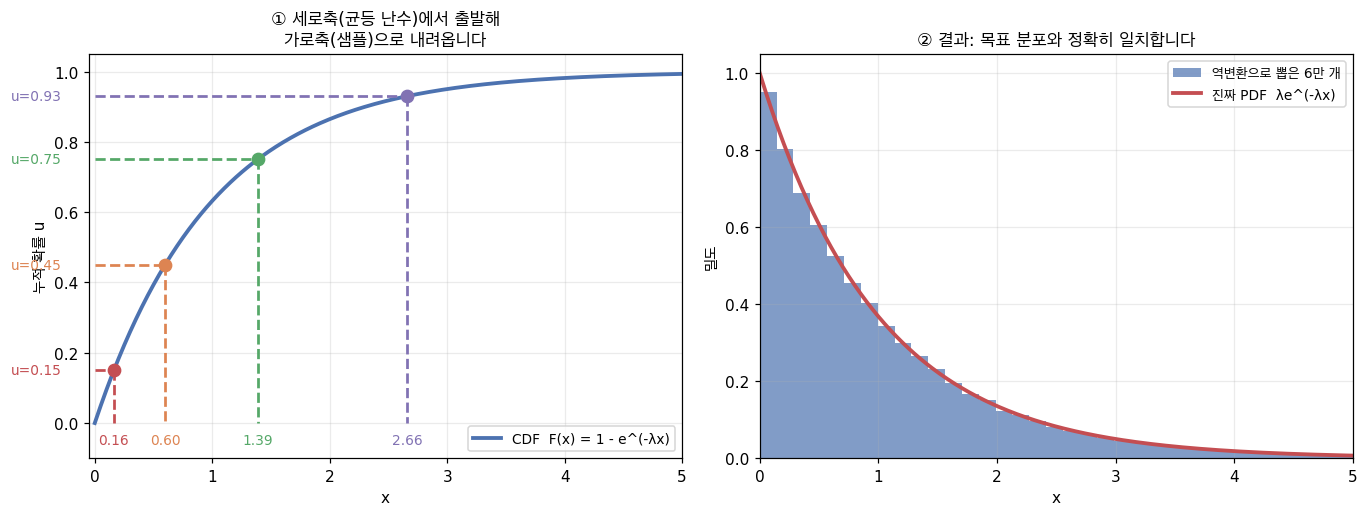

왼쪽 그림의 핵심: CDF가 가파른 구간(x가 작은 쪽)에는 u가 많이 배정되고,
완만한 구간에는 적게 배정됩니다. 그래서 자동으로 밀도가 높은 곳에서 많이 뽑히게 됩니다.
'CDF의 기울기 = 밀도'라는 사실이 그대로 샘플링 알고리즘이 된 셈입니다.


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8))

lam = 1.0
xs = np.linspace(0, 5, 400)
cdf = 1 - np.exp(-lam * xs)

ax1.plot(xs, cdf, lw=2.5, color="#4c72b0", label="CDF  F(x) = 1 - e^(-λx)")
random.seed(3)
demo_us = [0.15, 0.45, 0.75, 0.93]
colors = ["#c44e52", "#dd8452", "#55a868", "#8172b3"]
for u, c in zip(demo_us, colors):
    x = -math.log(1 - u) / lam
    ax1.plot([0, x], [u, u], color=c, lw=1.8, ls="--")
    ax1.plot([x, x], [u, 0], color=c, lw=1.8, ls="--")
    ax1.plot([x], [u], "o", color=c, ms=8)
    ax1.text(-0.28, u, f"u={u}", fontsize=9, color=c, ha="right", va="center")
    ax1.text(x, -0.06, f"{x:.2f}", fontsize=9, color=c, ha="center")
ax1.set_xlim(-0.05, 5); ax1.set_ylim(-0.1, 1.05)
ax1.set_xlabel("x"); ax1.set_ylabel("누적 확률 u")
ax1.set_title("① 세로축(균등 난수)에서 출발해\n가로축(샘플)으로 내려옵니다", fontsize=11.5)
ax1.legend(fontsize=9, loc="lower right"); ax1.grid(alpha=0.25)

random.seed(4)
samples = [sample_exponential_inverse_cdf(lam) for _ in range(60_000)]
ax2.hist(samples, bins=90, density=True, color="#4c72b0", alpha=0.7,
         label="역변환으로 뽑은 6만 개")
ax2.plot(xs, lam * np.exp(-lam * xs), lw=2.5, color="#c44e52", label="진짜 PDF  λe^(-λx)")
ax2.set_xlim(0, 5)
ax2.set_xlabel("x"); ax2.set_ylabel("밀도")
ax2.set_title("② 결과: 목표 분포와 정확히 일치합니다", fontsize=11.5)
ax2.legend(fontsize=9); ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("왼쪽 그림의 핵심: CDF가 가파른 구간(x가 작은 쪽)에는 u가 많이 배정되고,")
print("완만한 구간에는 적게 배정됩니다. 그래서 자동으로 밀도가 높은 곳에서 많이 뽑히게 됩니다.")
print("'CDF의 기울기 = 밀도'라는 사실이 그대로 샘플링 알고리즘이 된 셈입니다.")

## 3️⃣ 기각 샘플링 — 못 뒤집으면 던져서 맞히기

CDF를 뒤집을 수 없다면 어떻게 할까요? 대신 **목표 밀도 `p(x)`를 계산할 수는 있다면** 방법이 있습니다.
심지어 `p(x)`가 정규화되어 있지 않아도 됩니다.

아이디어는 다트 던지기에 가깝습니다.

> 목표 분포를 **완전히 덮는 큰 상자**를 씌운 다음, 그 상자 안에 다트를 무작위로 던집니다.
> 다트가 **곡선 아래에 떨어지면 채택**하고, 위에 떨어지면 버립니다.

```
목표 분포   : p(x)   — 계산은 가능 (정규화 안 되어도 OK)
제안 분포   : q(x)   — 여기서는 직접 뽑을 수 있음
덮개 상수   : M      — 모든 x에 대해 p(x) ≤ M·q(x)

알고리즘
  1. x ~ q(x) 를 뽑는다
  2. u ~ Uniform(0, 1) 을 뽑는다
  3. u < p(x) / (M·q(x)) 이면 x를 채택
  4. 아니면 버리고 1번으로 돌아간다

수용률 = 1/M
```

### 🔑 `M`이 왜 중요한가

`M`은 "덮개가 목표보다 얼마나 헐렁한가"를 나타냅니다.
**덮개가 딱 맞을수록(M이 1에 가까울수록) 버리는 샘플이 적습니다.**

### ⚠️ 그리고 이 방법의 치명적 약점

저차원(1~3차원)에서는 잘 동작합니다. 그런데 **차원이 올라가면 수용률이 지수적으로 떨어져요.**
고차원에서는 제안 분포의 부피 대부분이 목표 분포와 겹치지 않거든요.
이게 **기각 샘플링 판 차원의 저주**이고, 6절에서 MCMC가 필요해지는 이유입니다.

In [6]:
def rejection_sample(target_pdf, proposal_sample, proposal_pdf, M, max_tries=10_000):
    tries = 0
    while tries < max_tries:
        tries += 1
        x = proposal_sample()
        u = random.random()
        if u < target_pdf(x) / (M * proposal_pdf(x)):
            return x, tries
    raise RuntimeError("수용에 실패했습니다 - M이나 제안 분포를 확인하세요")

# 예제: [-2, 2]로 잘린 정규분포에서 뽑기. 제안은 그 구간의 균등분포입니다.
LO, HI = -2.0, 2.0
normal_pdf = lambda x: math.exp(-x * x / 2) / math.sqrt(2 * math.pi)
trunc_pdf = lambda x: normal_pdf(x) if LO <= x <= HI else 0.0
unif_pdf = lambda x: 1.0 / (HI - LO)
unif_sample = lambda: random.uniform(LO, HI)

M = normal_pdf(0.0) / unif_pdf(0.0)      # 최악의 비율 = 정규 최댓값 / 균등 밀도
print(f"덮개 상수 M = {M:.4f}   ->  이론 수용률 = 1/M = {1/M:.4f}")

random.seed(5)
samples, tries_list = [], []
for _ in range(30_000):
    x, t = rejection_sample(trunc_pdf, unif_sample, unif_pdf, M)
    samples.append(x)
    tries_list.append(t)

print(f"실제 수용률 = {len(samples)/sum(tries_list):.4f}   (샘플 {len(samples):,}개 얻는 데 시도 {sum(tries_list):,}회)")
print(f"표본 평균 = {np.mean(samples):.4f}  (대칭이므로 0이어야 합니다)")

print("\n[⚠️ 차원의 저주 확인] d차원 구를 감싸는 정육면체에 다트를 던져 봅니다")
print(f"{'차원 d':>8}{'수용률(=구 부피/정육면체 부피)':>34}{'샘플 1개당 평균 시도':>24}")
print("-" * 68)
rng = np.random.default_rng(9)
for d in [1, 2, 3, 5, 10, 20]:
    pts = rng.uniform(-1, 1, size=(200_000, d))
    inside = np.mean((pts ** 2).sum(axis=1) <= 1.0)
    tries = f"{1/inside:,.0f}회" if inside > 0 else "> 200,000회"
    print(f"{d:>8}{inside:>34.6f}{tries:>24}")
print("\n=> 20차원이면 다트를 수만 번 던져야 하나 겨우 맞습니다. 기각 샘플링은 여기서 무너집니다.")

덮개 상수 M = 1.5958   ->  이론 수용률 = 1/M = 0.6267
실제 수용률 = 0.6007   (샘플 30,000개 얻는 데 시도 49,945회)
표본 평균 = -0.0019  (대칭이므로 0이어야 합니다)

[⚠️ 차원의 저주 확인] d차원 구를 감싸는 정육면체에 다트를 던져 봅니다
    차원 d                수용률(=구 부피/정육면체 부피)            샘플 1개당 평균 시도
--------------------------------------------------------------------
       1                          1.000000                      1회
       2                          0.784470                      1회
       3                          0.524070                      2회
       5                          0.163680                      6회
      10                          0.002510                    398회
      20                          0.000000              > 200,000회

=> 20차원이면 다트를 수만 번 던져야 하나 겨우 맞습니다. 기각 샘플링은 여기서 무너집니다.


### 🖼️ 그림 2 — 채택과 기각을 눈으로 보기

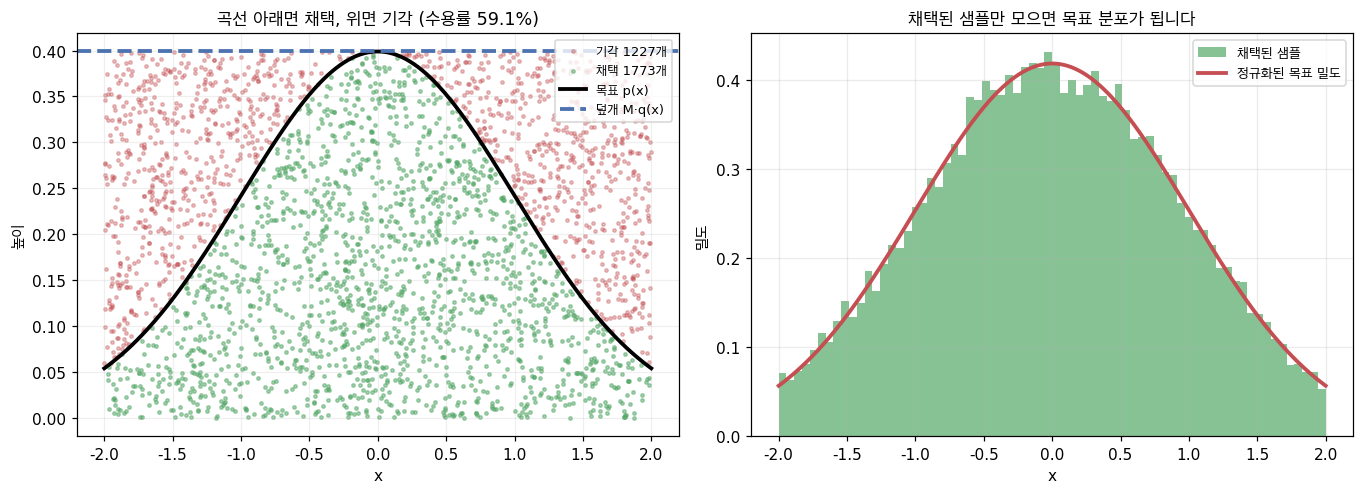

왼쪽에서 빨간 점(기각)이 차지하는 면적이 바로 낭비되는 계산입니다.
덮개(파란 선)를 목표 곡선에 더 가깝게 만들수록 빨간 영역이 줄어듭니다.
여기서는 균등분포를 덮개로 써서 꽤 헐렁했고, 그래서 40% 가까이 버렸습니다.


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))

random.seed(6)
acc_x, acc_y, rej_x, rej_y = [], [], [], []
for _ in range(3000):
    x = random.uniform(LO, HI)
    y = random.random() * M * unif_pdf(x)
    if y < trunc_pdf(x):
        acc_x.append(x); acc_y.append(y)
    else:
        rej_x.append(x); rej_y.append(y)

xs = np.linspace(LO, HI, 400)
ax1.scatter(rej_x, rej_y, s=5, color="#c44e52", alpha=0.35, label=f"기각 {len(rej_x)}개")
ax1.scatter(acc_x, acc_y, s=5, color="#55a868", alpha=0.5, label=f"채택 {len(acc_x)}개")
ax1.plot(xs, [trunc_pdf(x) for x in xs], lw=2.5, color="black", label="목표 p(x)")
ax1.axhline(M * unif_pdf(0), lw=2.5, color="#4c72b0", ls="--", label="덮개 M·q(x)")
ax1.set_xlabel("x"); ax1.set_ylabel("높이")
ax1.set_title(f"곡선 아래면 채택, 위면 기각 (수용률 {len(acc_x)/3000:.1%})", fontsize=11.5)
ax1.legend(fontsize=8.5, loc="upper right"); ax1.grid(alpha=0.2)

ax2.hist(samples, bins=70, density=True, color="#55a868", alpha=0.7, label="채택된 샘플")
Z = sum(trunc_pdf(x) for x in np.linspace(LO, HI, 4000)) * (HI - LO) / 4000
ax2.plot(xs, [trunc_pdf(x) / Z for x in xs], lw=2.5, color="#c44e52",
         label="정규화된 목표 밀도")
ax2.set_xlabel("x"); ax2.set_ylabel("밀도")
ax2.set_title("채택된 샘플만 모으면 목표 분포가 됩니다", fontsize=11.5)
ax2.legend(fontsize=9); ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("왼쪽에서 빨간 점(기각)이 차지하는 면적이 바로 낭비되는 계산입니다.")
print("덮개(파란 선)를 목표 곡선에 더 가깝게 만들수록 빨간 영역이 줄어듭니다.")
print("여기서는 균등분포를 덮개로 써서 꽤 헐렁했고, 그래서 40% 가까이 버렸습니다.")

## 4️⃣ 중요도 샘플링 — 다른 분포로 뽑고 가중치로 보정하기

여기서 질문을 살짝 바꿔 봅시다.

**우리가 진짜로 원하는 게 샘플일까요, 아니면 기댓값일까요?**

많은 경우 우리가 원하는 건 `E_p[f(x)]` 라는 **숫자 하나**입니다.
그렇다면 굳이 `p`에서 샘플을 뽑을 필요가 없습니다. 다른 분포 `q`에서 뽑고 **보정**하면 되거든요.

$$E_p[f(x)] = \int f(x)p(x)dx = \int f(x)\frac{p(x)}{q(x)}q(x)dx = E_q\!\left[f(x)\,w(x)\right]$$

여기서 `w(x) = p(x)/q(x)` 를 **중요도 가중치**라고 부릅니다.

$$E_p[f(x)] \approx \frac{1}{N}\sum_i f(x_i)\,w(x_i), \qquad x_i \sim q$$

직관은 이렇습니다. `q`에서 뽑으면 어떤 영역은 **과다 표집**되고 어떤 영역은 **과소 표집**됩니다.
가중치 `p/q`가 그 불균형을 정확히 상쇄해 줍니다.
`q`가 많이 뽑은 곳은 가중치를 낮추고, 적게 뽑은 곳은 가중치를 높이는 거죠.

### 🏭 강화학습에서 결정적으로 쓰입니다

**PPO(Proximal Policy Optimization)** 를 생각해 보세요.
궤적은 **예전 정책 `π_old`** 로 수집했는데, 최적화하고 싶은 건 **새 정책 `π_new`** 입니다.
매번 새로 데이터를 모으는 건 너무 비싸니까요.

이때 중요도 가중치가 정확히 `π_new(a|s) / π_old(a|s)` 입니다.
그리고 PPO의 그 유명한 **클리핑**은, 이 가중치가 너무 커지지 않도록 잘라내는 장치예요.

### ⚠️ 왜 클리핑이 필요한가 — 분산 문제

추정량의 분산은 **`q`가 `p`와 얼마나 닮았는지**에 달려 있습니다.
`q`가 `p`와 많이 다르면 **몇 개의 샘플이 어마어마한 가중치를 받아 추정치를 지배**합니다.
샘플 1000개를 썼는데 실질적으로는 3개만 기여하는 상황이 생겨요.

이걸 완화하는 방법 중 하나가 **자기정규화 중요도 샘플링**입니다.

$$E_p[f(x)] \approx \frac{\sum_i w_i f(x_i)}{\sum_i w_i}$$

가중치 합으로 나눠 주면 편향이 약간 생기지만 분산이 크게 줄어듭니다.

In [8]:
def importance_sampling(f, target_pdf, proposal_pdf, proposal_sample, n, self_normalized=False):
    num, denom = 0.0, 0.0
    for _ in range(n):
        x = proposal_sample()
        w = target_pdf(x) / proposal_pdf(x)
        num += f(x) * w
        denom += w
    return num / denom if self_normalized else num / n

# 목표: 표준정규분포에서 E[x²] 을 구합니다. 정답은 분산 = 1 입니다.
target = lambda x: math.exp(-x * x / 2) / math.sqrt(2 * math.pi)
f = lambda x: x * x

random.seed(11)
print("E_p[x²] under N(0,1) 을 서로 다른 제안 분포로 추정합니다 (정답 = 1.0)\n")
print(f"{'제안 분포 q':<28}{'일반 추정':>14}{'자기정규화':>14}{'유효 표본수':>14}")
print("-" * 72)

proposals = [
    ("Uniform(-5, 5)   좋음", lambda: random.uniform(-5, 5), lambda x: 1 / 10 if -5 <= x <= 5 else 1e-300),
    ("Uniform(-2, 2)   너무 좁음", lambda: random.uniform(-2, 2), lambda x: 1 / 4 if -2 <= x <= 2 else 1e-300),
    ("Uniform(-20, 20) 너무 넓음", lambda: random.uniform(-20, 20), lambda x: 1 / 40 if -20 <= x <= 20 else 1e-300),
]
N_IS = 50_000
for name, qs, qp in proposals:
    random.seed(11)
    plain = importance_sampling(f, target, qp, qs, N_IS)
    random.seed(11)
    selfn = importance_sampling(f, target, qp, qs, N_IS, self_normalized=True)
    random.seed(11)
    w_list = []
    for _ in range(N_IS):
        x = qs()
        w_list.append(target(x) / qp(x))
    w_arr = np.array(w_list)
    ess = w_arr.sum() ** 2 / (w_arr ** 2).sum()      # 유효 표본 크기
    print(f"{name:<28}{plain:>14.4f}{selfn:>14.4f}{ess:>14,.0f}")

print(f"\n(유효 표본 크기 ESS = (Σw)² / Σw² — 실제로 몇 개 몫을 하고 있는지를 나타냅니다. 최대 {N_IS:,})")
print("\n=> 제안이 너무 좁으면(-2, 2): 꼬리를 아예 못 봐서 값이 아래로 편향됩니다.")
print("   제안이 너무 넓으면(-20, 20): 대부분의 샘플이 가중치 ~0이라 유효 표본이 확 줄어듭니다.")
print("   좋은 제안 분포란 '목표 분포가 있는 곳에 샘플을 집중시키는' 분포입니다.")

E_p[x²] under N(0,1) 을 서로 다른 제안 분포로 추정합니다 (정답 = 1.0)

제안 분포 q                              일반 추정         자기정규화        유효 표본수
------------------------------------------------------------------------
Uniform(-5, 5)   좋음                 0.9987        1.0002        17,697
Uniform(-2, 2)   너무 좁음              0.7388        0.7749        40,527
Uniform(-20, 20) 너무 넓음              1.0017        1.0039         4,432

(유효 표본 크기 ESS = (Σw)² / Σw² — 실제로 몇 개 몫을 하고 있는지를 나타냅니다. 최대 50,000)

=> 제안이 너무 좁으면(-2, 2): 꼬리를 아예 못 봐서 값이 아래로 편향됩니다.
   제안이 너무 넓으면(-20, 20): 대부분의 샘플이 가중치 ~0이라 유효 표본이 확 줄어듭니다.
   좋은 제안 분포란 '목표 분포가 있는 곳에 샘플을 집중시키는' 분포입니다.


### 🖼️ 그림 3 — 나쁜 제안 분포가 만드는 가중치 폭발

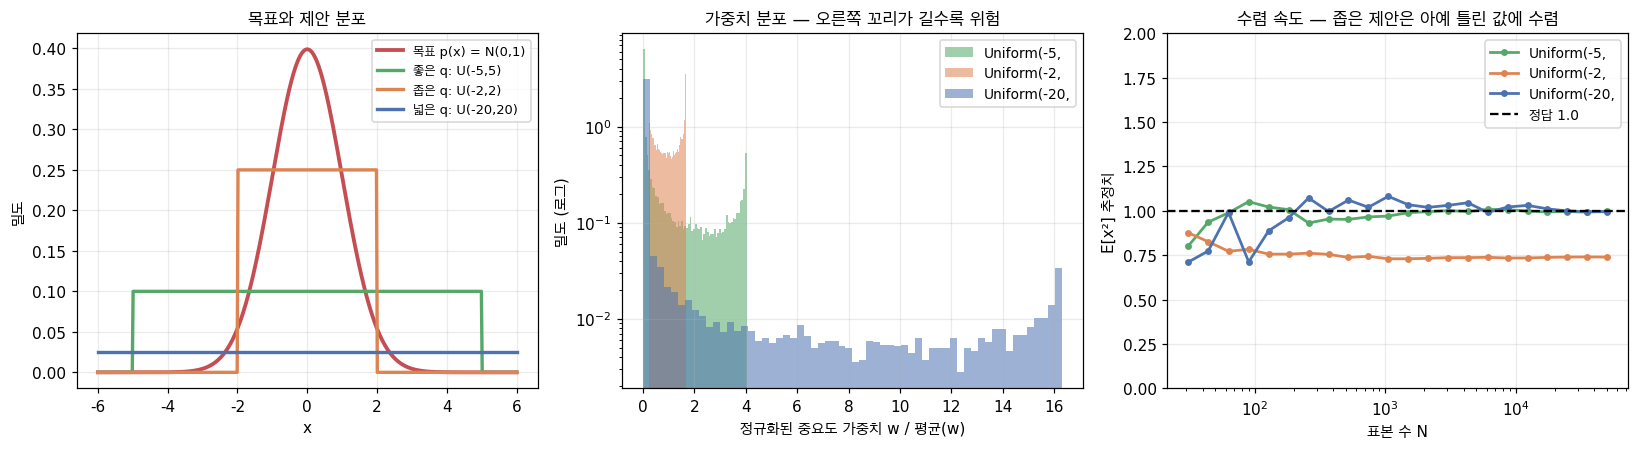

가운데 그림이 PPO 클리핑이 존재하는 이유입니다.
가중치 분포에 긴 꼬리가 생기면, 샘플 하나가 그래디언트 전체를 흔들어 버립니다.
PPO는 이 비율을 [1-ε, 1+ε]로 잘라서 그런 사고를 막습니다.


In [9]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.2))

xs = np.linspace(-6, 6, 500)
ax1.plot(xs, [target(x) for x in xs], lw=2.5, color="#c44e52", label="목표 p(x) = N(0,1)")
ax1.plot(xs, [1/10 if -5 <= x <= 5 else 0 for x in xs], lw=2.2, color="#55a868",
         label="좋은 q: U(-5,5)")
ax1.plot(xs, [1/4 if -2 <= x <= 2 else 0 for x in xs], lw=2.2, color="#dd8452",
         label="좁은 q: U(-2,2)")
ax1.plot(xs, [1/40 if -20 <= x <= 20 else 0 for x in xs], lw=2.2, color="#4c72b0",
         label="넓은 q: U(-20,20)")
ax1.set_title("목표와 제안 분포", fontsize=11.5)
ax1.set_xlabel("x"); ax1.set_ylabel("밀도")
ax1.legend(fontsize=8.5); ax1.grid(alpha=0.25)

# 가중치 분포
random.seed(12)
for (name, qs, qp), color in zip(proposals, ["#55a868", "#dd8452", "#4c72b0"]):
    random.seed(12)
    w = np.array([target(x) / qp(x) for x in [qs() for _ in range(20_000)]])
    ax2.hist(w / w.mean(), bins=60, alpha=0.55, color=color, label=name.split()[0],
             density=True, log=True)
ax2.set_xlabel("정규화된 중요도 가중치 w / 평균(w)")
ax2.set_ylabel("밀도 (로그)")
ax2.set_title("가중치 분포 — 오른쪽 꼬리가 길수록 위험", fontsize=11.5)
ax2.legend(fontsize=9); ax2.grid(alpha=0.25)

# 표본 수에 따른 수렴
ns = np.unique(np.logspace(1.5, 4.7, 22).astype(int))
for (name, qs, qp), color in zip(proposals, ["#55a868", "#dd8452", "#4c72b0"]):
    ests = []
    for n in ns:
        random.seed(13)
        ests.append(importance_sampling(f, target, qp, qs, int(n)))
    ax3.semilogx(ns, ests, "o-", ms=3.5, color=color, lw=1.8, label=name.split()[0])
ax3.axhline(1.0, color="black", ls="--", lw=1.5, label="정답 1.0")
ax3.set_xlabel("표본 수 N"); ax3.set_ylabel("E[x²] 추정치")
ax3.set_ylim(0, 2)
ax3.set_title("수렴 속도 — 좁은 제안은 아예 틀린 값에 수렴", fontsize=11.5)
ax3.legend(fontsize=9); ax3.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("가운데 그림이 PPO 클리핑이 존재하는 이유입니다.")
print("가중치 분포에 긴 꼬리가 생기면, 샘플 하나가 그래디언트 전체를 흔들어 버립니다.")
print("PPO는 이 비율을 [1-ε, 1+ε]로 잘라서 그런 사고를 막습니다.")

## 5️⃣ 몬테카를로 추정 — 차원의 저주를 피하는 유일한 길

몬테카를로는 **적분을 무작위 샘플의 평균으로 근사**합니다. 큰 수의 법칙이 수렴을 보장해 주죠.

```
목표: I = ∫_D g(x) dx

방법:
  1. D에서 x_1, ..., x_N 을 균등하게 뽑는다
  2. I ≈ (D의 부피 / N) × Σ g(x_i)

오차: O(1/√N)   ← 차원과 무관합니다
```

### 🔑 마지막 줄이 이 방법의 존재 이유입니다

**오차가 차원에 의존하지 않습니다.** 이게 얼마나 대단한 일인지 비교해 볼게요.

격자 기반 수치적분은 차원 `d`에서 정확도를 유지하려면 점이 `N^d`개 필요합니다.
10차원이면 격자점 10개씩만 잡아도 100억 개예요. 계산이 불가능합니다.

반면 몬테카를로는 **10차원이든 1000차원이든 오차가 `1/√N`** 입니다.
그래서 고차원에서는 사실상 유일한 선택지가 됩니다.

다만 `1/√N`은 **느립니다.** 정확도를 10배 올리려면 샘플이 **100배** 필요해요.
이 느린 수렴 속도를 개선하려는 게 12절의 층화 샘플링, 그리고 준몬테카를로 같은 기법들입니다.

In [10]:
def monte_carlo_pi(n, seed=0):
    rng = np.random.default_rng(seed)
    pts = rng.uniform(-1, 1, size=(n, 2))
    inside = int(((pts ** 2).sum(axis=1) <= 1).sum())
    return 4 * inside / n

print("π 추정 — 정사각형에 다트를 던져 원 안에 든 비율을 셉니다")
print(f"{'샘플 수 N':>14}{'추정 π':>14}{'절대 오차':>14}{'1/√N':>14}")
print("-" * 58)
for n in [100, 1_000, 10_000, 100_000, 1_000_000, 10_000_000]:
    est = monte_carlo_pi(n, seed=42)
    print(f"{n:>14,}{est:>14.6f}{abs(est - math.pi):>14.6f}{1/math.sqrt(n):>14.6f}")

print("\n=> 오차가 1/√N 열과 같은 규모로 줄어듭니다.")
print("   샘플을 100배 늘려야 오차가 10배 줄어드는, 느리지만 확실한 수렴입니다.")

print("\n[기댓값 추정에도 그대로 씁니다]")
rng = np.random.default_rng(3)
for n in [100, 10_000, 1_000_000]:
    x = rng.normal(0, 1, n)
    print(f"  N={n:>9,}:  E[x²] 추정 {np.mean(x**2):.5f}  (정답 1),  "
          f"E[|x|] 추정 {np.mean(np.abs(x)):.5f}  (정답 {math.sqrt(2/math.pi):.5f})")

π 추정 — 정사각형에 다트를 던져 원 안에 든 비율을 셉니다
        샘플 수 N          추정 π         절대 오차          1/√N
----------------------------------------------------------
           100      3.280000      0.138407      0.100000
         1,000      3.116000      0.025593      0.031623
        10,000      3.138800      0.002793      0.010000
       100,000      3.135400      0.006193      0.003162
     1,000,000      3.143256      0.001663      0.001000
    10,000,000      3.141730      0.000137      0.000316

=> 오차가 1/√N 열과 같은 규모로 줄어듭니다.
   샘플을 100배 늘려야 오차가 10배 줄어드는, 느리지만 확실한 수렴입니다.

[기댓값 추정에도 그대로 씁니다]
  N=      100:  E[x²] 추정 1.14085  (정답 1),  E[|x|] 추정 0.83618  (정답 0.79788)
  N=   10,000:  E[x²] 추정 1.00472  (정답 1),  E[|x|] 추정 0.80380  (정답 0.79788)
  N=1,000,000:  E[x²] 추정 0.99981  (정답 1),  E[|x|] 추정 0.79773  (정답 0.79788)


### 🖼️ 그림 4 — 오차가 정말 1/√N 으로 줄어드는가

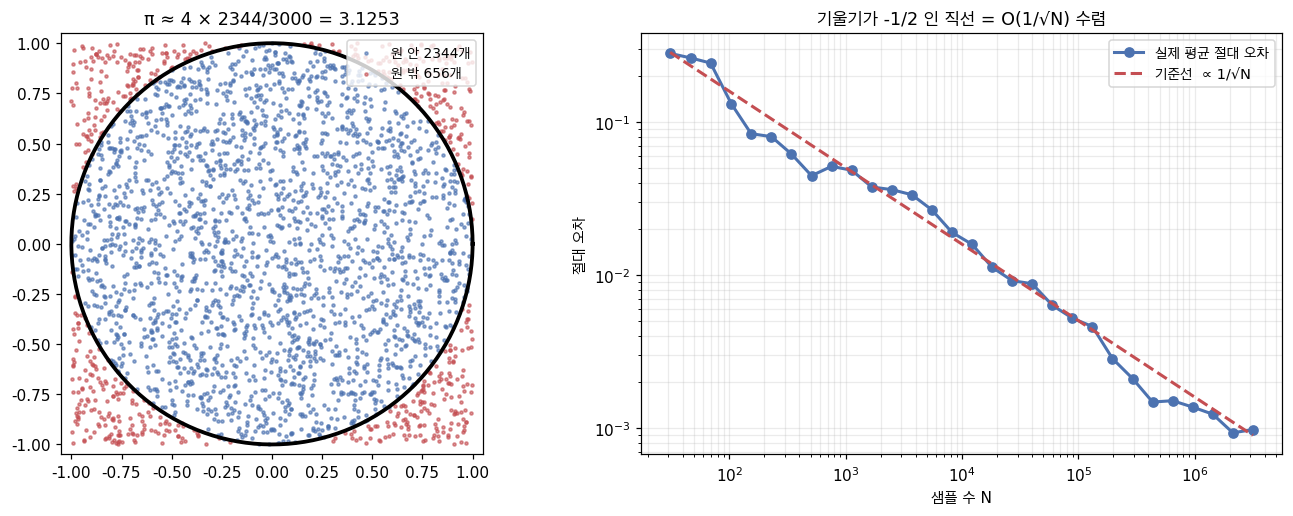

로그-로그 기울기 측정값 = -0.5062   (이론값 -0.5)

이 -0.5라는 숫자가 몬테카를로의 정체성입니다.
차원이 1이든 1000이든 이 기울기는 변하지 않습니다. 그게 이 방법의 힘이자 한계입니다.


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8))

rng = np.random.default_rng(1)
pts = rng.uniform(-1, 1, size=(3000, 2))
inside = (pts ** 2).sum(axis=1) <= 1
ax1.scatter(pts[inside, 0], pts[inside, 1], s=4, color="#4c72b0", alpha=0.6,
            label=f"원 안 {inside.sum()}개")
ax1.scatter(pts[~inside, 0], pts[~inside, 1], s=4, color="#c44e52", alpha=0.6,
            label=f"원 밖 {(~inside).sum()}개")
th = np.linspace(0, 2 * np.pi, 300)
ax1.plot(np.cos(th), np.sin(th), lw=2.5, color="black")
ax1.set_aspect("equal"); ax1.set_xlim(-1.05, 1.05); ax1.set_ylim(-1.05, 1.05)
ax1.set_title(f"π ≈ 4 × {inside.sum()}/3000 = {4*inside.sum()/3000:.4f}", fontsize=11.5)
ax1.legend(fontsize=9, loc="upper right")

ns = np.unique(np.logspace(1.5, 6.5, 30).astype(int))
errs = []
for n in ns:
    trials = [abs(monte_carlo_pi(int(n), seed=s) - math.pi) for s in range(12)]
    errs.append(np.mean(trials))
ax2.loglog(ns, errs, "o-", color="#4c72b0", lw=2, label="실제 평균 절대 오차")
ax2.loglog(ns, 1.6 / np.sqrt(ns), "--", color="#c44e52", lw=2, label="기준선  ∝ 1/√N")
ax2.set_xlabel("샘플 수 N"); ax2.set_ylabel("절대 오차")
ax2.set_title("기울기가 -1/2 인 직선 = O(1/√N) 수렴", fontsize=11.5)
ax2.legend(fontsize=9.5); ax2.grid(alpha=0.25, which="both")

plt.tight_layout()
plt.show()

slope = np.polyfit(np.log(ns), np.log(errs), 1)[0]
print(f"로그-로그 기울기 측정값 = {slope:.4f}   (이론값 -0.5)")
print("\n이 -0.5라는 숫자가 몬테카를로의 정체성입니다.")
print("차원이 1이든 1000이든 이 기울기는 변하지 않습니다. 그게 이 방법의 힘이자 한계입니다.")

## 6️⃣ MCMC: Metropolis-Hastings

이제 가장 어려운 상황입니다. **고차원이라 기각 샘플링이 무너지고, CDF도 못 뒤집는 경우.**
게다가 흔히 목표 분포는 **정규화 상수를 모릅니다.** 베이즈 사후분포가 딱 그렇죠.
분자는 계산할 수 있지만 분모(증거)는 적분이 불가능한 경우요.

MCMC의 발상은 완전히 다릅니다.

> **독립적인 샘플을 하나씩 만들려 하지 말고,
> 목표 분포를 정상분포(stationary distribution)로 갖는 마르코프 연쇄를 만들자.**

연쇄를 충분히 오래 돌리면, 그 연쇄가 방문하는 지점들이 곧 목표 분포의 샘플이 됩니다.

### 📐 Metropolis-Hastings 알고리즘

```
목표: p(x)  (정규화 상수는 몰라도 됩니다)
제안: q(x'|x)  (현재 위치에서 다음 후보를 어떻게 제안할지)

  1. 아무 데서나 x_0 로 시작한다
  2. t = 1, 2, ..., T 에 대해:
     a. 후보 x' ~ q(x'|x_t) 를 제안한다
     b. 수용 비율을 계산한다:
        α = [p(x')·q(x_t|x')] / [p(x_t)·q(x'|x_t)]
     c. min(1, α) 의 확률로 수용한다:
        - u < α 이면  x_{t+1} = x'   (이동)
        - 아니면      x_{t+1} = x_t  (제자리)
  3. 앞의 B개는 버린다 (번인, burn-in)
  4. 나머지를 샘플로 쓴다
```

제안이 **대칭**이면(`q(x'|x) = q(x|x')`) 비율이 그냥 `p(x')/p(x)` 로 단순해집니다. 이게 원조 Metropolis 알고리즘이에요.

### 🔑 여기서 마법이 일어납니다

수용 비율이 **밀도의 비**라는 점을 보세요. `p(x')/p(x)` 에서는 **정규화 상수가 약분됩니다.**
그래서 **분모를 몰라도 샘플링이 가능**한 겁니다. 이게 MCMC가 베이즈 추론의 표준 도구가 된 이유예요.

**왜 작동하는가**는 **상세 균형(detailed balance)** 으로 설명됩니다.
"x에 있다가 x'로 갈 확률"과 "x'에 있다가 x로 갈 확률"이 같도록 수용 규칙을 설계했고,
이 조건이 성립하면 `p(x)`가 그 연쇄의 정상분포가 된다는 게 수학적으로 보장됩니다.

### ⚠️ 실무에서 신경 쓸 것들

- **번인(burn-in)**: 연쇄가 평형에 도달하기 전 초기 샘플은 버립니다
- **씨닝(thinning)**: 연속된 샘플은 상관되어 있으니 k개마다 하나씩 취하기도 합니다
- **제안 폭(proposal scale)**: 이게 제일 중요합니다
  - 너무 작으면 → 수용률은 높은데 **제자리걸음**만 합니다
  - 너무 크면 → 대부분 기각되어 **한 점에 붙박입니다**
  - 고차원 가우시안 제안의 **최적 수용률은 약 0.234**로 알려져 있습니다

In [12]:
def metropolis_hastings(target_log_pdf, x0, proposal_std, n_samples, burn_in, seed=0):
    rng = random.Random(seed)
    x = x0
    samples, accepted = [], 0
    for i in range(n_samples + burn_in):
        x_new = x + rng.gauss(0, proposal_std)          # 대칭 제안 -> 비율이 단순해집니다
        log_alpha = target_log_pdf(x_new) - target_log_pdf(x)
        if math.log(rng.random()) < log_alpha:
            x = x_new
            if i >= burn_in:
                accepted += 1
        if i >= burn_in:
            samples.append(x)
    return samples, accepted / n_samples

# 목표: 두 개의 봉우리를 가진 분포. 정규화 상수는 일부러 안 넣었습니다.
def bimodal_log_pdf(x):
    a = math.exp(-0.5 * ((x + 2.0) / 0.7) ** 2)
    b = 0.6 * math.exp(-0.5 * ((x - 2.5) / 1.0) ** 2)
    return math.log(a + b + 1e-300)

# 먼저 참값을 수치적분으로 구해 둡니다 (비교 기준)
grid = np.linspace(-8, 10, 20_000)
dens = np.exp([bimodal_log_pdf(x) for x in grid])
dens /= dens.sum()
true_mean = float((grid * dens).sum())
true_right = float(dens[grid > 0.25].sum())      # 오른쪽 봉우리가 차지하는 확률 질량
print(f"참값(수치적분): 평균 {true_mean:.4f},  오른쪽 봉우리의 질량 비중 {true_right:.4f}\n")

print("제안 폭(proposal_std)을 바꿔가며 같은 분포를 샘플링해 봅니다.")
print("한 번만 돌리면 운에 좌우되므로, 각 설정마다 서로 다른 시드로 6번씩 돌려 평균을 냅니다.\n")
print(f"{'제안 폭':>10}{'수용률':>10}{'평균 절대오차':>16}"
      f"{'오른쪽 봉우리 비중':>20}{'진단':>20}")
print("-" * 78)
chains = {}
for std in [0.05, 0.5, 2.0, 8.0, 50.0]:
    errs, accs, rights = [], [], []
    for seed in range(1, 7):
        smp, acc = metropolis_hastings(bimodal_log_pdf, 0.0, std, 40_000, 5_000, seed=seed)
        errs.append(abs(np.mean(smp) - true_mean))
        accs.append(acc)
        rights.append(float(np.mean(np.array(smp) > 0.25)))
        if seed == 1:
            chains[std] = (smp, acc)          # 그림용으로 첫 시드를 보관합니다
    acc_m = float(np.mean(accs))
    if acc_m > 0.9:
        diag = "제자리걸음"
    elif acc_m < 0.1:
        diag = "붙박이"
    elif 0.2 <= acc_m <= 0.6:
        diag = "양호 (권장 구간)"
    else:
        diag = "그럭저럭"
    print(f"{std:>10.2f}{acc_m:>10.3f}{np.mean(errs):>16.4f}"
          f"{np.mean(rights):>20.4f}{diag:>20}")

print(f"\n(참 평균 {true_mean:.4f}, 참 '오른쪽 봉우리 비중' {true_right:.4f})")
print("\n=> 세 가지를 읽어야 합니다.")
print("   ① 제안 폭 0.05: 오차가 압도적으로 큽니다(1.9). '오른쪽 봉우리 비중'도 참값 "
      f"{true_right:.2f} 대신 0.24입니다.")
print("      한 걸음이 너무 작아 두 봉우리 사이 골짜기를 거의 건너지 못한 탓입니다. 명백한 실패입니다.")
print("   ② 제안 폭 2~8: 오차가 가장 작습니다. 수용률도 0.2~0.5 권장 구간에 들어옵니다.")
print("      이론적으로 알려진 '최적 수용률 약 0.234'와도 잘 맞습니다.")
print("   ③ 제안 폭 50: 오차 자체는 나쁘지 않습니다. 움직이기만 하면 멀리 가니까요.")
print("      문제는 비용입니다 — 96%가 기각되므로 사실상 계산의 96%를 버립니다.")
print(f"      40,000 스텝 중 실제로 이동한 횟수는 약 {0.041*40000:,.0f}번뿐입니다.")
print("      즉 '틀린다'기보다 '같은 정확도를 얻는 데 훨씬 비싸다'가 정확한 표현입니다.")

참값(수치적분): 평균 0.0769,  오른쪽 봉우리의 질량 비중 0.4562

제안 폭(proposal_std)을 바꿔가며 같은 분포를 샘플링해 봅니다.
한 번만 돌리면 운에 좌우되므로, 각 설정마다 서로 다른 시드로 6번씩 돌려 평균을 냅니다.

      제안 폭       수용률         평균 절대오차          오른쪽 봉우리 비중                  진단
------------------------------------------------------------------------------
      0.05     0.980          1.9408              0.2447               제자리걸음
      0.50     0.818          0.2664              0.4718                그럭저럭
      2.00     0.512          0.0416              0.4585          양호 (권장 구간)
      8.00     0.236          0.0396              0.4587          양호 (권장 구간)
     50.00     0.041          0.0460              0.4524                 붙박이

(참 평균 0.0769, 참 '오른쪽 봉우리 비중' 0.4562)

=> 세 가지를 읽어야 합니다.
   ① 제안 폭 0.05: 오차가 압도적으로 큽니다(1.9). '오른쪽 봉우리 비중'도 참값 0.46 대신 0.24입니다.
      한 걸음이 너무 작아 두 봉우리 사이 골짜기를 거의 건너지 못한 탓입니다. 명백한 실패입니다.
   ② 제안 폭 2~8: 오차가 가장 작습니다. 수용률도 0.2~0.5 권장 구간에 들어옵니다.
      이론적으로 알려진 '최적 수용률 약 0.234'와도 잘 맞습니다.
   ③ 제안 폭 50: 오차 자체는 나쁘지 않습니다. 움직이기

### 🖼️ 그림 5 — 제안 폭이 연쇄의 운명을 가릅니다

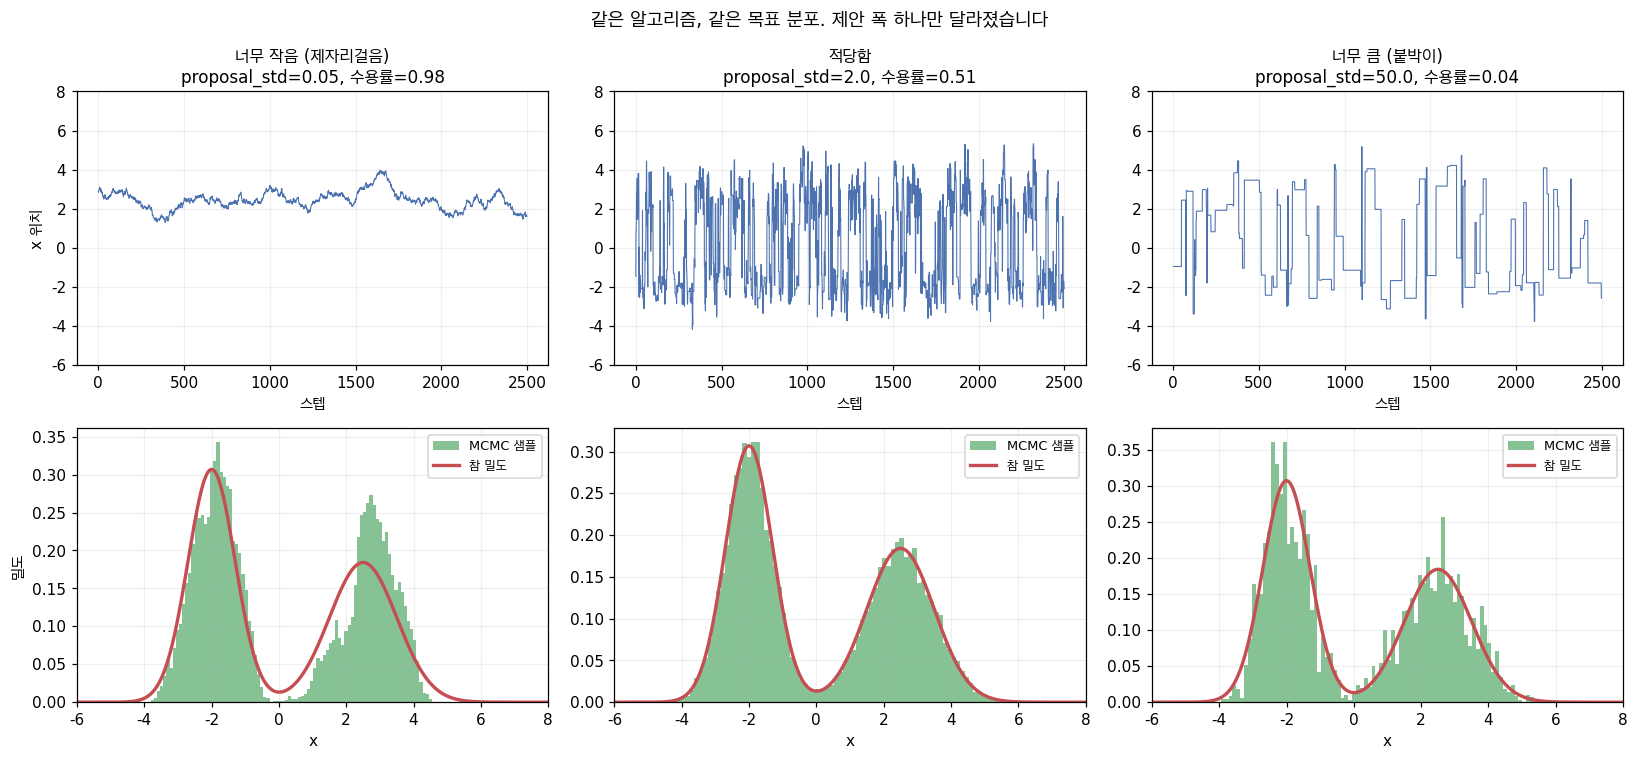

왼쪽(폭 0.05): 수용률 0.982,  이 시드에서의 평균 오차 0.1818
가운데(폭 2.0): 수용률 0.512,  이 시드에서의 평균 오차 0.0216
오른쪽(폭 50.0): 수용률 0.042,  이 시드에서의 평균 오차 0.0767

왼쪽: 한 걸음이 너무 작아 두 봉우리 사이의 골짜기를 넘는 일이 드뭅니다.
가운데: 두 봉우리를 자유롭게 오갑니다. 히스토그램이 참 밀도에 가장 잘 붙었습니다.
오른쪽: 제안이 너무 멀어 거의 다 기각됩니다. 궤적이 계단처럼 평평한 구간투성이입니다.

💡 수용률은 MCMC를 진단하는 가장 값싼 지표입니다. 0.2~0.5 밖이면 제안 폭부터 의심하세요.

[번인 확인] 아주 엉뚱한 곳(x=40)에서 시작하면:
  처음 10 스텝: [44.68, 43.35, 45.02, 42.22, 40.07, 38.38, 36.57, 36.57, 36.57, 35.78]
  평형에 도달하기까지 대략 36스텝 걸렸습니다.
  이 초기 구간을 버리는 게 번인(burn-in)입니다.


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
show = [0.05, 2.0, 50.0]
titles = ["너무 작음 (제자리걸음)", "적당함", "너무 큼 (붙박이)"]

for col, (std, title) in enumerate(zip(show, titles)):
    s, acc = chains[std]
    # 위: 연쇄의 궤적
    ax = axes[0][col]
    ax.plot(s[:2500], lw=0.7, color="#4c72b0")
    ax.set_title(f"{title}\nproposal_std={std}, 수용률={acc:.2f}", fontsize=11)
    ax.set_ylim(-6, 8)
    ax.set_xlabel("스텝");
    if col == 0:
        ax.set_ylabel("x 위치")
    ax.grid(alpha=0.2)
    # 아래: 히스토그램 vs 참 밀도
    ax = axes[1][col]
    ax.hist(s, bins=90, density=True, color="#55a868", alpha=0.7, label="MCMC 샘플")
    ax.plot(grid, dens / (grid[1] - grid[0]), lw=2.2, color="#c44e52", label="참 밀도")
    ax.set_xlim(-6, 8)
    ax.set_xlabel("x")
    if col == 0:
        ax.set_ylabel("밀도")
    ax.legend(fontsize=8.5)
    ax.grid(alpha=0.2)

plt.suptitle("같은 알고리즘, 같은 목표 분포. 제안 폭 하나만 달라졌습니다", fontsize=12.5)
plt.tight_layout()
plt.show()

for std, label in zip(show, ["왼쪽", "가운데", "오른쪽"]):
    ss, acc = chains[std]
    print(f"{label}(폭 {std}): 수용률 {acc:.3f},  이 시드에서의 평균 오차 "
          f"{abs(np.mean(ss)-true_mean):.4f}")
print("\n왼쪽: 한 걸음이 너무 작아 두 봉우리 사이의 골짜기를 넘는 일이 드뭅니다.")
print("가운데: 두 봉우리를 자유롭게 오갑니다. 히스토그램이 참 밀도에 가장 잘 붙었습니다.")
print("오른쪽: 제안이 너무 멀어 거의 다 기각됩니다. 궤적이 계단처럼 평평한 구간투성이입니다.")
print("\n💡 수용률은 MCMC를 진단하는 가장 값싼 지표입니다. 0.2~0.5 밖이면 제안 폭부터 의심하세요.")

# 번인이 필요한 이유
s_bad, _ = metropolis_hastings(bimodal_log_pdf, 40.0, 2.0, 3000, 0, seed=2)
print(f"\n[번인 확인] 아주 엉뚱한 곳(x=40)에서 시작하면:")
print(f"  처음 10 스텝: {[round(v,2) for v in s_bad[:10]]}")
print(f"  평형에 도달하기까지 대략 {next(i for i,v in enumerate(s_bad) if abs(v) < 6)}스텝 걸렸습니다.")
print("  이 초기 구간을 버리는 게 번인(burn-in)입니다.")

## 7️⃣ 깁스 샘플링 — 한 번에 한 변수씩

깁스 샘플링은 다변량 분포를 위한 MCMC의 특수한 형태입니다.

Metropolis-Hastings는 모든 차원을 **한꺼번에** 옮기려 합니다.
고차원에서는 그게 어렵죠. 어느 방향으로 얼마나 움직여야 할지 알기 힘드니까요.

깁스는 발상을 바꿉니다. **한 번에 한 변수씩, 나머지를 고정한 채로 그 변수의 조건부 분포에서 뽑습니다.**

```
목표: p(x_1, x_2, ..., x_d)

각 반복마다:
  x_1 ~ p(x_1 | x_2, x_3, ..., x_d)     ← 나머지는 현재 값으로 고정
  x_2 ~ p(x_2 | x_1, x_3, ..., x_d)     ← 방금 갱신한 x_1을 씁니다
  ...
  x_d ~ p(x_d | x_1, ..., x_{d-1})
```

### 🔑 수용률이 항상 1입니다

제안을 기각하는 일이 없습니다. **정확한 조건부 분포에서 뽑는 것 자체가 이미 상세 균형을 만족**하기 때문이에요.
버리는 계산이 없다는 게 큰 장점입니다.

물론 조건부 분포에서 뽑을 수 있어야 쓸 수 있습니다. 다행히 많은 모델에서 이게 쉬워요.

- **베이지안 네트워크**: 조건부가 그래프 구조에서 바로 나옵니다
- **가우시안 혼합**: 조건부도 가우시안입니다
- **이징 모형**: 각 스핀의 조건부는 이웃에만 의존합니다

### ⚠️ 약점: 상관이 강하면 느립니다

변수들이 강하게 상관되어 있으면 깁스는 **매우 느리게 섞입니다.**
한 번에 한 축씩만 움직이니까 **대각선 방향으로 큰 걸음을 못 내딛거든요.**
아래 그림에서 지그재그 궤적으로 직접 확인해 보겠습니다.

In [14]:
def gibbs_2d_gaussian(rho, n_samples, burn_in, seed=0):
    # 2D 표준 가우시안(상관 rho)의 조건부는 해석적으로 알려져 있습니다:
    #   x | y ~ N(rho*y, 1 - rho²)
    rng = random.Random(seed)
    cond_std = math.sqrt(1 - rho ** 2)
    x, y = 0.0, 0.0
    samples, path = [], []
    for i in range(n_samples + burn_in):
        x = rng.gauss(rho * y, cond_std)
        if i >= burn_in:
            path.append((x, y))
        y = rng.gauss(rho * x, cond_std)
        if i >= burn_in:
            path.append((x, y))
            samples.append((x, y))
    return samples, path

print("2D 가우시안에서 깁스 샘플링 — 상관이 커질수록 어떻게 되는지 봅니다\n")
print(f"{'상관 ρ':>10}{'표본 상관':>14}{'x의 자기상관(lag1)':>22}{'진단':>20}")
print("-" * 68)
gibbs_results = {}
for rho in [0.0, 0.5, 0.9, 0.99]:
    s, path = gibbs_2d_gaussian(rho, 20_000, 1_000, seed=1)
    arr = np.array(s)
    gibbs_results[rho] = (arr, path)
    emp_corr = float(np.corrcoef(arr[:, 0], arr[:, 1])[0, 1])
    ac = float(np.corrcoef(arr[:-1, 0], arr[1:, 0])[0, 1])
    diag = "빠름" if ac < 0.5 else ("느림" if ac < 0.9 else "매우 느림")
    print(f"{rho:>10.2f}{emp_corr:>14.4f}{ac:>22.4f}{diag:>20}")

print("\n=> 목표 상관은 정확히 재현합니다(2열). 문제는 '얼마나 빨리 섞이느냐'(3열)입니다.")
print("   ρ=0.99면 연속된 샘플이 거의 같은 값이라, 20,000개를 뽑아도 실질적 정보량은 훨씬 적습니다.")

# 유효 표본 크기 비교
print(f"\n{'상관 ρ':>10}{'명목 표본수':>16}{'유효 표본수(ESS 근사)':>26}")
print("-" * 54)
for rho, (arr, _) in gibbs_results.items():
    ac = float(np.corrcoef(arr[:-1, 0], arr[1:, 0])[0, 1])
    ess = len(arr) * (1 - ac) / (1 + ac)         # AR(1) 가정하의 근사
    print(f"{rho:>10.2f}{len(arr):>16,}{ess:>26,.0f}")

2D 가우시안에서 깁스 샘플링 — 상관이 커질수록 어떻게 되는지 봅니다

      상관 ρ         표본 상관         x의 자기상관(lag1)                  진단
--------------------------------------------------------------------
      0.00       -0.0043               -0.0045                  빠름
      0.50        0.5035                0.2444                  빠름
      0.90        0.9011                0.8083                  느림
      0.99        0.9894                0.9786               매우 느림

=> 목표 상관은 정확히 재현합니다(2열). 문제는 '얼마나 빨리 섞이느냐'(3열)입니다.
   ρ=0.99면 연속된 샘플이 거의 같은 값이라, 20,000개를 뽑아도 실질적 정보량은 훨씬 적습니다.

      상관 ρ          명목 표본수            유효 표본수(ESS 근사)
------------------------------------------------------
      0.00          20,000                    20,179
      0.50          20,000                    12,144
      0.90          20,000                     2,120
      0.99          20,000                       216


### 🖼️ 그림 6 — 깁스가 지그재그로만 움직이는 모습

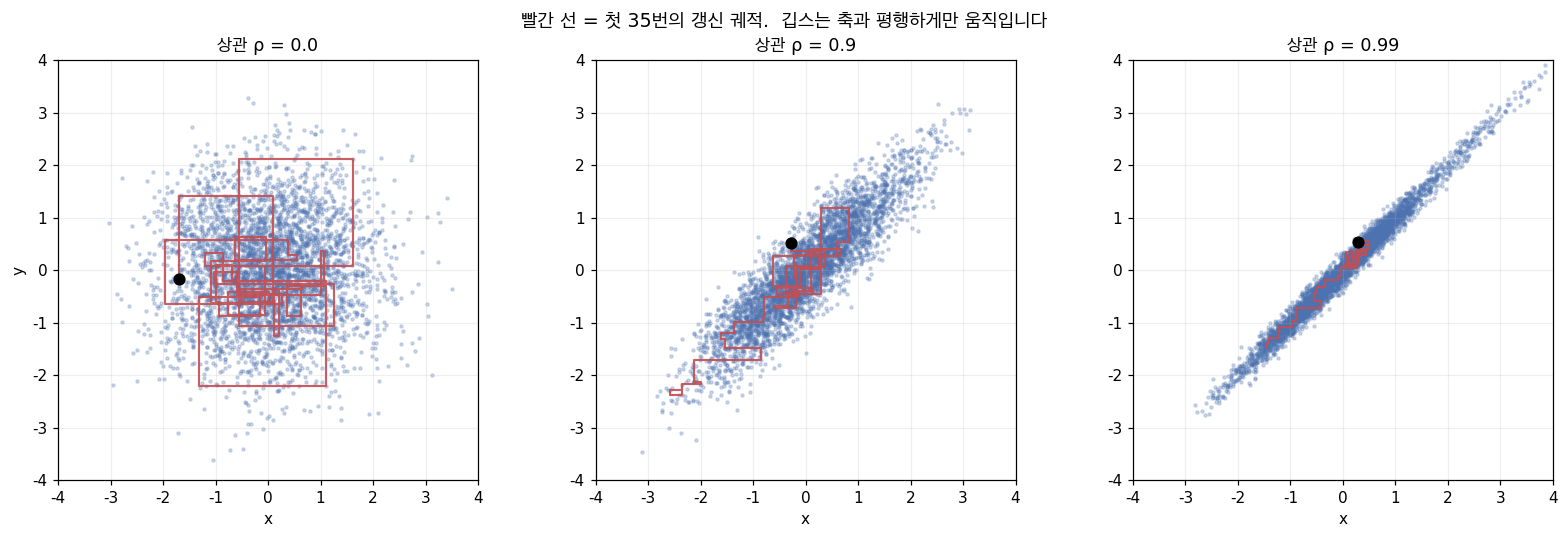

오른쪽 그림을 보세요. 분포가 좁고 긴 대각선 모양인데,
깁스는 가로·세로로만 움직일 수 있어서 그 대각선을 따라 '기어갈' 수밖에 없습니다.
한 걸음의 크기가 조건부 분포의 폭 √(1-ρ²)에 갇히기 때문입니다.
  ρ=0.99 일 때 조건부 표준편차 = 0.1411  <- 이만큼씩밖에 못 움직입니다.

💡 그래서 실무에서는 변수를 묶어서 갱신하거나(block Gibbs),
   HMC/NUTS처럼 기울기를 이용해 대각선으로 크게 움직이는 방법을 씁니다.


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

for ax, rho in zip(axes, [0.0, 0.9, 0.99]):
    arr, path = gibbs_results[rho]
    ax.scatter(arr[:4000, 0], arr[:4000, 1], s=4, alpha=0.25, color="#4c72b0")
    p = np.array(path[:70])
    ax.plot(p[:, 0], p[:, 1], color="#c44e52", lw=1.4, alpha=0.9)
    ax.plot(p[0, 0], p[0, 1], "o", color="black", ms=7)
    ax.set_title(f"상관 ρ = {rho}", fontsize=11.5)
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4); ax.set_aspect("equal")
    ax.set_xlabel("x"); ax.grid(alpha=0.2)
axes[0].set_ylabel("y")
plt.suptitle("빨간 선 = 첫 35번의 갱신 궤적.  깁스는 축과 평행하게만 움직입니다", fontsize=12.5)
plt.tight_layout()
plt.show()

print("오른쪽 그림을 보세요. 분포가 좁고 긴 대각선 모양인데,")
print("깁스는 가로·세로로만 움직일 수 있어서 그 대각선을 따라 '기어갈' 수밖에 없습니다.")
print("한 걸음의 크기가 조건부 분포의 폭 √(1-ρ²)에 갇히기 때문입니다.")
print(f"  ρ=0.99 일 때 조건부 표준편차 = {math.sqrt(1-0.99**2):.4f}  <- 이만큼씩밖에 못 움직입니다.")
print("\n💡 그래서 실무에서는 변수를 묶어서 갱신하거나(block Gibbs),")
print("   HMC/NUTS처럼 기울기를 이용해 대각선으로 크게 움직이는 방법을 씁니다.")

## 8️⃣ 🔨 Temperature 샘플링 — LLM의 그 손잡이

이제 0절의 문제로 돌아옵니다. 5만 개 logit 중에서 하나를 고르는 문제요.

언어모델은 어휘의 각 토큰에 대해 logit `z_1, ..., z_V` 를 내놓고, softmax가 그걸 확률로 바꿉니다.
**temperature는 softmax를 먹이기 전에 logit을 나눠 주는 값**입니다.

$$p_i = \frac{e^{z_i/T}}{\sum_j e^{z_j/T}}$$

### 📐 왜 이게 작동하는가

`T < 1`로 나누면 **logit 사이의 차이가 증폭**됩니다.
`z₁ = 2`, `z₂ = 1` 일 때 `T = 0.5`로 나누면 4와 2가 되죠. 격차가 두 배로 벌어집니다.
그리고 softmax는 지수함수라서, 벌어진 격차가 확률에서는 훨씬 크게 나타납니다.

```
T = 1.0 : 원래 분포 그대로
T → 0   : argmax (결정론적, 항상 최고 logit)
T → ∞   : 균등분포 (모든 토큰이 동등)
T < 1   : 분포가 뾰족해짐 (확신↑, 다양성↓)
T > 1   : 분포가 평평해짐 (확신↓, 다양성↑)
```

### 🏭 실무 설정값

| T | 용도 |
| --- | --- |
| 0.0 | 탐욕 디코딩. 사실 기반 Q&A |
| 0.3 ~ 0.7 | 약간의 창의성. 코드 생성에 적합 |
| 0.7 ~ 1.0 | 균형. 일반 대화 |
| 1.0 ~ 1.5 | 창작, 브레인스토밍 |
| > 1.5 | 점점 무작위. 거의 쓸모 없음 |

> ⚠️ **중요한 구분:** temperature는 **어떤 토큰이 가능한지를 바꾸지 않습니다.**
> 확률 질량이 각 토큰에 얼마나 배분되는지만 바꿉니다.
> 확률이 0.0001인 이상한 토큰도 여전히 후보로 남아 있어요. 그걸 잘라내는 게 9절의 top-k와 top-p입니다.

In [16]:
def temperature_softmax(logits, T):
    if T <= 1e-8:                                  # T -> 0 은 argmax
        out = [0.0] * len(logits)
        out[max(range(len(logits)), key=lambda i: logits[i])] = 1.0
        return out
    return softmax([z / T for z in logits])

def temperature_sample(logits, T):
    return sample_from_probs(temperature_softmax(logits, T))

print("같은 logit, 서로 다른 temperature\n")
header = f"{'토큰':<8}{'logit':>8}"
for T in [0.2, 0.5, 1.0, 1.5, 3.0]:
    header += f"{'T=' + str(T):>10}"
print(header)
print("-" * 66)
for i, (w, l) in enumerate(zip(VOCAB, LOGITS)):
    row = f"{w:<8}{l:>8.1f}"
    for T in [0.2, 0.5, 1.0, 1.5, 3.0]:
        row += f"{temperature_softmax(LOGITS, T)[i]:>10.4f}"
    print(row)

print("\n분포의 '뾰족함'을 엔트로피로 재 봅니다 (낮을수록 확신, 높을수록 다양)")
print(f"{'T':>8}{'엔트로피(bits)':>18}{'최빈 토큰 확률':>18}{'퍼플렉서티':>14}")
print("-" * 60)
for T in [0.0, 0.2, 0.5, 0.7, 1.0, 1.5, 3.0, 10.0]:
    p = temperature_softmax(LOGITS, T)
    ent = abs(-sum(pi * math.log2(pi) for pi in p if pi > 0))
    print(f"{T:>8.1f}{ent:>18.4f}{max(p):>18.4f}{2**ent:>14.2f}")
print(f"\n(균등분포의 엔트로피 = log2({len(VOCAB)}) = {math.log2(len(VOCAB)):.4f} bits — T가 커지면 여기로 수렴합니다)")

print("\n실제로 뽑아 보면 (각 T마다 20번)")
for T in [0.2, 1.0, 3.0]:
    random.seed(99)
    out = [VOCAB[temperature_sample(LOGITS, T)] for _ in range(20)]
    uniq = len(set(out))
    print(f"  T={T}:  {' '.join(out)}")
    print(f"        서로 다른 토큰 {uniq}종")

같은 logit, 서로 다른 temperature

토큰         logit     T=0.2     T=0.5     T=1.0     T=1.5     T=3.0
------------------------------------------------------------------
고양이          3.2    0.8796    0.6460    0.4438    0.3345    0.2094
강아지          2.8    0.1190    0.2903    0.2975    0.2562    0.1833
새            1.9    0.0013    0.0480    0.1209    0.1406    0.1358
물고기          1.1    0.0000    0.0097    0.0543    0.0825    0.1040
나무           0.6    0.0000    0.0036    0.0330    0.0591    0.0880
돌            0.2    0.0000    0.0016    0.0221    0.0453    0.0770
구름          -0.3    0.0000    0.0006    0.0134    0.0324    0.0652
바다          -0.8    0.0000    0.0002    0.0081    0.0232    0.0552
산           -1.4    0.0000    0.0001    0.0045    0.0156    0.0452
별           -2.0    0.0000    0.0000    0.0024    0.0104    0.0370

분포의 '뾰족함'을 엔트로피로 재 봅니다 (낮을수록 확신, 높을수록 다양)
       T        엔트로피(bits)          최빈 토큰 확률         퍼플렉서티
------------------------------------------------------------
    

### 🖼️ 그림 7 — temperature가 분포를 어떻게 주무르는가

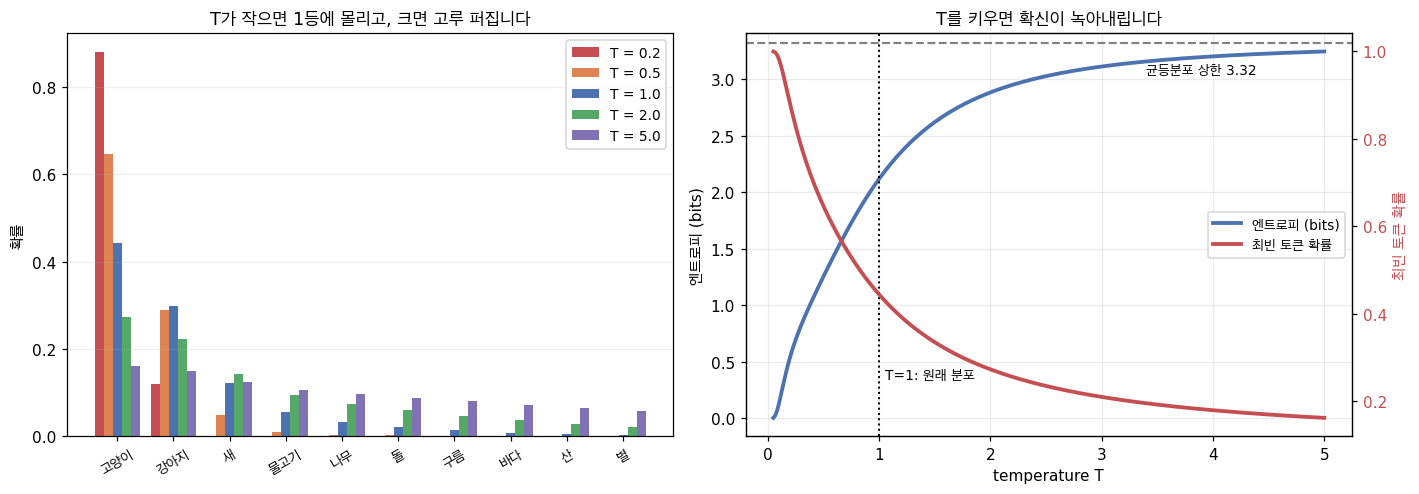

오른쪽 그림에서 T=1을 기준으로 왼쪽은 '더 확신하게', 오른쪽은 '더 헤매게' 만듭니다.
그런데 주목할 점: T를 아무리 키워도 최빈 토큰 확률은 1/10(=균등) 아래로 못 내려갑니다.
temperature는 순위를 바꾸지 못하기 때문입니다. 1등은 T와 무관하게 계속 1등입니다.


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

Ts = [0.2, 0.5, 1.0, 2.0, 5.0]
width = 0.16
idx = np.arange(len(VOCAB))
for k, (T, color) in enumerate(zip(Ts, ["#c44e52", "#dd8452", "#4c72b0", "#55a868", "#8172b3"])):
    p = temperature_softmax(LOGITS, T)
    ax1.bar(idx + (k - 2) * width, p, width=width, color=color, label=f"T = {T}")
ax1.set_xticks(idx); ax1.set_xticklabels(VOCAB, fontsize=9, rotation=30)
ax1.set_ylabel("확률")
ax1.set_title("T가 작으면 1등에 몰리고, 크면 고루 퍼집니다", fontsize=11.5)
ax1.legend(fontsize=9); ax1.grid(alpha=0.2, axis="y")

T_range = np.linspace(0.05, 5, 300)
ents, tops = [], []
for T in T_range:
    p = temperature_softmax(LOGITS, float(T))
    ents.append(-sum(pi * math.log2(pi) for pi in p if pi > 0))
    tops.append(max(p))
ax2.plot(T_range, ents, lw=2.5, color="#4c72b0", label="엔트로피 (bits)")
ax2.axhline(math.log2(len(VOCAB)), ls="--", color="gray", lw=1.4)
ax2.text(3.4, math.log2(len(VOCAB)) - 0.28, f"균등분포 상한 {math.log2(len(VOCAB)):.2f}", fontsize=9)
ax2.set_xlabel("temperature T"); ax2.set_ylabel("엔트로피 (bits)")
ax2b = ax2.twinx()
ax2b.plot(T_range, tops, lw=2.5, color="#c44e52", label="최빈 토큰 확률")
ax2b.set_ylabel("최빈 토큰 확률", color="#c44e52")
ax2b.tick_params(axis="y", labelcolor="#c44e52")
ax2.axvline(1.0, color="black", ls=":", lw=1.3)
ax2.text(1.05, 0.35, "T=1: 원래 분포", fontsize=9)
ax2.set_title("T를 키우면 확신이 녹아내립니다", fontsize=11.5)
lines = ax2.get_lines()[:1] + ax2b.get_lines()[:1]
ax2.legend(lines, [l.get_label() for l in lines], fontsize=9, loc="center right")
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("오른쪽 그림에서 T=1을 기준으로 왼쪽은 '더 확신하게', 오른쪽은 '더 헤매게' 만듭니다.")
print("그런데 주목할 점: T를 아무리 키워도 최빈 토큰 확률은 1/10(=균등) 아래로 못 내려갑니다.")
print("temperature는 순위를 바꾸지 못하기 때문입니다. 1등은 T와 무관하게 계속 1등입니다.")

## 9️⃣ 🔨 Top-k와 Top-p (nucleus) — 꼬리를 잘라내기

temperature만으로는 부족한 이유가 있습니다.
어휘가 5만 개인데, 확률 0.00001짜리 이상한 토큰이 **4만 개** 있다고 해 봅시다.
개별 확률은 무시할 만해도 **다 합치면 0.4**입니다. 꽤 자주 뽑힌다는 뜻이에요.

그래서 아예 **후보를 잘라냅니다.**

### 📐 Top-k 샘플링

```
1. 전체 V개 토큰의 softmax 확률을 구한다
2. 확률 내림차순으로 정렬한다
3. 상위 k개만 남긴다
4. 재정규화한다: p_i' = p_i / Σ(상위 k개의 p)
5. 그 안에서 샘플링한다

k = 1  : 탐욕 디코딩
k = V  : 필터링 없음
k = 40 : 일반적인 설정
```

**문제가 하나 있습니다.** `k`가 **문맥과 무관하게 고정**이라는 점이에요.

- 모델이 확신할 때 (한 토큰이 95%): k=40이면 **쓸데없는 39개 대안**을 남겨 둡니다
- 모델이 헷갈릴 때 (확률이 1000개에 퍼져 있음): k=40이면 **그럴듯한 후보들을 잘라냅니다**

### 📐 Top-p (nucleus) 샘플링

여기서 발상을 뒤집습니다. **개수를 고정하지 말고 확률 질량을 고정합시다.**

```
1. softmax 확률을 구한다
2. 내림차순 정렬한다
3. 누적 확률이 p를 넘는 가장 작은 집합을 찾는다
4. 그 집합만 남기고 재정규화한 뒤 샘플링한다

p = 0.9 : 확률 질량의 90%를 덮는 토큰들
p = 1.0 : 필터링 없음
p = 0.1 : 매우 제한적, 거의 탐욕
```

**후보 집합의 크기가 문맥에 따라 자동으로 바뀝니다.**
확신할 때는 2~3개만 남고, 헷갈릴 때는 200개까지 남습니다.
이 **적응성**이 nucleus 샘플링이 일반적으로 더 나은 텍스트를 만드는 이유입니다.

### 🏭 자주 쓰는 조합

- **temperature 0.7 + top-p 0.9** — 범용으로 무난합니다
- **temperature 0.0 (탐욕)** — 결정론적 작업
- **temperature 1.0 + top-k 50** — Fan et al. (2018) 원논문 설정

top-k와 top-p는 **함께 쓸 수도 있습니다.** 보통 top-k를 먼저 적용하고 남은 집합에 top-p를 겁니다.

In [18]:
def top_k_filter(probs, k):
    idx = sorted(range(len(probs)), key=lambda i: -probs[i])[:k]
    total = sum(probs[i] for i in idx)
    out = [0.0] * len(probs)
    for i in idx:
        out[i] = probs[i] / total
    return out, sorted(idx)

def top_p_filter(probs, p):
    order = sorted(range(len(probs)), key=lambda i: -probs[i])
    cum, keep = 0.0, []
    for i in order:
        keep.append(i)
        cum += probs[i]
        if cum >= p:
            break
    total = sum(probs[i] for i in keep)
    out = [0.0] * len(probs)
    for i in keep:
        out[i] = probs[i] / total
    return out, sorted(keep)

# 두 가지 문맥을 만듭니다: 모델이 확신하는 경우와 헷갈리는 경우
CONFIDENT = [8.0, 2.0, 1.5, 1.0, 0.5, 0.2, -0.5, -1.0, -1.5, -2.0]
UNCERTAIN = [1.2, 1.1, 1.0, 0.95, 0.9, 0.85, 0.8, 0.75, 0.7, 0.6]

for tag, lg in [("모델이 확신하는 문맥", CONFIDENT), ("모델이 헷갈리는 문맥", UNCERTAIN)]:
    p = softmax(lg)
    print(f"\n=== {tag} ===")
    print(f"  확률 상위 5개: {[round(v,4) for v in sorted(p, reverse=True)[:5]]}")
    print(f"  엔트로피: {-sum(v*math.log2(v) for v in p if v>0):.3f} bits")
    for k in [3, 5]:
        _, kept = top_k_filter(p, k)
        print(f"  top-k={k}  -> 후보 {len(kept)}개 (항상 {k}개, 문맥과 무관)")
    for pp in [0.9, 0.95]:
        _, kept = top_p_filter(p, pp)
        print(f"  top-p={pp} -> 후보 {len(kept)}개  <- 문맥에 따라 자동 조절")

print("\n" + "=" * 70)
print("top-p의 적응성을 더 큰 어휘에서 확인해 봅시다 (어휘 1000개)")
print("=" * 70)
rng = np.random.default_rng(17)
print(f"{'문맥의 확신 정도':>18}{'엔트로피':>12}{'top-k=40 후보':>16}{'top-p=0.9 후보':>18}")
print("-" * 66)
for sharpness, label in [(6.0, "매우 확신"), (2.0, "확신"), (0.7, "보통"), (0.2, "매우 불확실")]:
    lg = list(rng.normal(0, 1, 1000) * sharpness)
    p = softmax(lg)
    ent = -sum(v * math.log2(v) for v in p if v > 0)
    _, k_kept = top_k_filter(p, 40)
    _, p_kept = top_p_filter(p, 0.9)
    print(f"{label:>18}{ent:>12.2f}{len(k_kept):>16}{len(p_kept):>18}")
print("\n=> top-k는 무슨 일이 있어도 40개입니다. top-p는 2개에서 수백 개까지 스스로 조절합니다.")


=== 모델이 확신하는 문맥 ===
  확률 상위 5개: [0.9937, 0.0025, 0.0015, 0.0009, 0.0005]
  엔트로피: 0.070 bits
  top-k=3  -> 후보 3개 (항상 3개, 문맥과 무관)
  top-k=5  -> 후보 5개 (항상 5개, 문맥과 무관)
  top-p=0.9 -> 후보 1개  <- 문맥에 따라 자동 조절
  top-p=0.95 -> 후보 1개  <- 문맥에 따라 자동 조절

=== 모델이 헷갈리는 문맥 ===
  확률 상위 5개: [0.1349, 0.1221, 0.1105, 0.1051, 0.1]
  엔트로피: 3.300 bits
  top-k=3  -> 후보 3개 (항상 3개, 문맥과 무관)
  top-k=5  -> 후보 5개 (항상 5개, 문맥과 무관)
  top-p=0.9 -> 후보 9개  <- 문맥에 따라 자동 조절
  top-p=0.95 -> 후보 10개  <- 문맥에 따라 자동 조절

top-p의 적응성을 더 큰 어휘에서 확인해 봅시다 (어휘 1000개)
         문맥의 확신 정도        엔트로피     top-k=40 후보      top-p=0.9 후보
------------------------------------------------------------------
             매우 확신        1.26              40                 2
                확신        6.60              40               187
                보통        9.61              40               721
            매우 불확실        9.94              40               860

=> top-k는 무슨 일이 있어도 40개입니다. top-p는 2개에서 수백 개까지 스스로 조절합니다.


### 🖼️ 그림 8 — 같은 손잡이, 다른 철학

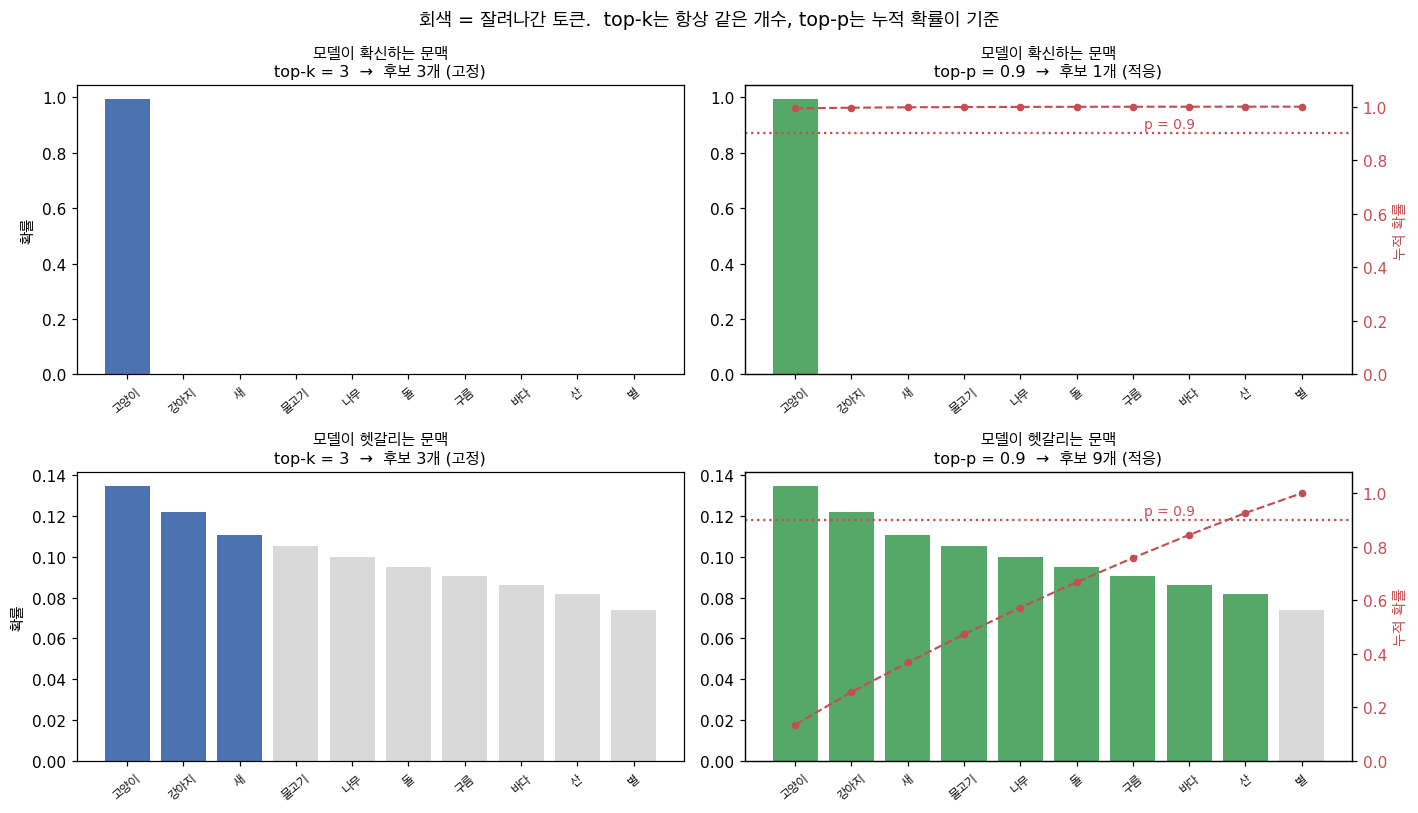

윗줄(확신): top-p는 1개만 남깁니다. 첫 토큰이 이미 확률의 99%를 갖고 있으니까요.
아랫줄(헷갈림): top-p는 9개를 남깁니다. 질량이 퍼져 있으니 더 많이 봐야 90%가 채워집니다.
반면 top-k는 두 경우 모두 기계적으로 3개입니다. 확신할 때는 쓸데없이 넓고,
헷갈릴 때는 지나치게 좁습니다. 이 '고정 vs 적응'이 두 방법의 결정적인 차이입니다.


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))

for row, (tag, lg) in enumerate([("모델이 확신하는 문맥", CONFIDENT),
                                 ("모델이 헷갈리는 문맥", UNCERTAIN)]):
    p = softmax(lg)
    order = sorted(range(len(p)), key=lambda i: -p[i])
    sorted_p = [p[i] for i in order]
    labels = [VOCAB[i] for i in order]

    _, k_kept = top_k_filter(p, 3)
    _, p_kept = top_p_filter(p, 0.9)
    k_mask = [i in k_kept for i in order]
    p_mask = [i in p_kept for i in order]

    ax = axes[row][0]
    ax.bar(range(len(p)), sorted_p,
           color=["#4c72b0" if m else "#d9d9d9" for m in k_mask])
    ax.set_xticks(range(len(p))); ax.set_xticklabels(labels, fontsize=8, rotation=40)
    ax.set_title(f"{tag}\ntop-k = 3  →  후보 {sum(k_mask)}개 (고정)", fontsize=10.5)
    ax.set_ylabel("확률")

    ax = axes[row][1]
    ax.bar(range(len(p)), sorted_p,
           color=["#55a868" if m else "#d9d9d9" for m in p_mask])
    cum = np.cumsum(sorted_p)
    ax2 = ax.twinx()
    ax2.plot(range(len(p)), cum, "o--", color="#c44e52", ms=4, lw=1.4)
    ax2.axhline(0.9, color="#c44e52", ls=":", lw=1.5)
    ax2.text(6.2, 0.92, "p = 0.9", fontsize=9, color="#c44e52")
    ax2.set_ylim(0, 1.08); ax2.set_ylabel("누적 확률", color="#c44e52")
    ax2.tick_params(axis="y", labelcolor="#c44e52")
    ax.set_xticks(range(len(p))); ax.set_xticklabels(labels, fontsize=8, rotation=40)
    ax.set_title(f"{tag}\ntop-p = 0.9  →  후보 {sum(p_mask)}개 (적응)", fontsize=10.5)

plt.suptitle("회색 = 잘려나간 토큰.  top-k는 항상 같은 개수, top-p는 누적 확률이 기준", fontsize=12.5)
plt.tight_layout()
plt.show()

n_conf = len(top_p_filter(softmax(CONFIDENT), 0.9)[1])
n_unc = len(top_p_filter(softmax(UNCERTAIN), 0.9)[1])
print(f"윗줄(확신): top-p는 {n_conf}개만 남깁니다. 첫 토큰이 이미 확률의 99%를 갖고 있으니까요.")
print(f"아랫줄(헷갈림): top-p는 {n_unc}개를 남깁니다. 질량이 퍼져 있으니 더 많이 봐야 90%가 채워집니다.")
print("반면 top-k는 두 경우 모두 기계적으로 3개입니다. 확신할 때는 쓸데없이 넓고,")
print("헷갈릴 때는 지나치게 좁습니다. 이 '고정 vs 적응'이 두 방법의 결정적인 차이입니다.")

## 🔟 재매개변수화 트릭 — 랜덤을 뚫고 역전파하기

VAE는 입력을 **잠재 공간의 분포**로 인코딩하고, 거기서 샘플링한 뒤, 그 샘플을 디코딩합니다.
그런데 여기 심각한 문제가 있습니다.

> **샘플링 연산을 통과해서는 역전파를 할 수 없습니다.**

```
z ~ N(μ, σ²)

μ를 조금 바꾸면 z가 어떻게 변할까요?
"샘플링 결과"를 μ로 미분한다는 게 말이 되나요?  d/dμ [N(μ,σ²)에서 뽑기] = ???
```

무작위성이 그래디언트의 흐름을 끊어 버립니다.

### 🔑 해결책: 무작위성을 파라미터 바깥으로 밀어내기

$$\varepsilon \sim N(0,1) \quad\text{(파라미터 없는 순수 노이즈)}$$
$$z = \mu + \sigma \cdot \varepsilon \quad\text{(파라미터의 결정론적 함수)}$$

이렇게 쓰면 `z`는 **`μ`와 `σ`의 미분 가능한 함수**가 됩니다.

$$\frac{\partial z}{\partial \mu} = 1, \qquad \frac{\partial z}{\partial \sigma} = \varepsilon$$

그래디언트가 흐릅니다.

이게 가능한 이유는 **`N(μ, σ²)`와 `μ + σ·N(0,1)`이 같은 분포**이기 때문입니다.
분포는 그대로 두고, **무작위성의 출처만 파라미터가 없는 곳으로 옮긴** 거예요.

### 📐 VAE 학습 루프에서

```
1. 인코더가 각 입력에 대해 μ와 log(σ²)를 출력
2. ε ~ N(0, 1) 을 샘플링
3. z = μ + σ·ε 를 계산
4. z를 디코딩해서 입력을 재구성
5. 4 → 3 → 2 → 1 로 역전파 (3번이 미분 가능하기 때문에 가능)
```

**이 트릭 하나가 VAE를 실용적으로 만들었습니다.** 없었다면 표준 역전파로 학습이 불가능했어요.

### 💡 대안과의 비교 — 왜 이게 더 나은가

사실 무작위성을 뚫는 다른 방법도 있습니다. **점수 함수 추정량(REINFORCE)** 인데요,
이건 미분 가능성을 요구하지 않는 대신 **분산이 훨씬 큽니다.**

아래에서 두 추정량의 분산을 직접 비교해 보겠습니다. 차이가 극적입니다.

In [20]:
# 목표: J(μ) = E_{z~N(μ,σ²)}[z²] 의 μ에 대한 그래디언트를 추정합니다.
# 해석적 정답: J(μ) = μ² + σ² 이므로 dJ/dμ = 2μ 입니다.

MU, SIGMA = 2.0, 1.0
TRUE_GRAD = 2 * MU

def score_function_grad(n, seed):
    # REINFORCE: ∇E[f] = E[f(z) · ∇log q(z)],  ∇_μ log N(z;μ,σ²) = (z-μ)/σ²
    rng = np.random.default_rng(seed)
    z = rng.normal(MU, SIGMA, n)
    return (z ** 2) * (z - MU) / SIGMA ** 2

def reparam_grad(n, seed):
    # z = μ + σε 이므로 ∇_μ f(z) = f'(z) · dz/dμ = 2z · 1
    rng = np.random.default_rng(seed)
    eps = rng.normal(0, 1, n)
    z = MU + SIGMA * eps
    return 2 * z

print(f"추정 대상: dJ/dμ,  정답 = {TRUE_GRAD}\n")
print(f"{'표본 수':>10}{'점수함수 추정':>18}{'점수함수 표준오차':>22}{'재매개변수화':>18}{'재매개변수화 표준오차':>26}")
print("-" * 96)
for n in [10, 100, 1_000, 10_000]:
    sf = score_function_grad(n, 0)
    rp = reparam_grad(n, 0)
    print(f"{n:>10,}{sf.mean():>18.4f}{sf.std()/math.sqrt(n):>22.4f}"
          f"{rp.mean():>18.4f}{rp.std()/math.sqrt(n):>26.4f}")

sf = score_function_grad(100_000, 1)
rp = reparam_grad(100_000, 1)
print(f"\n샘플 하나당 그래디언트 분산")
print(f"  점수함수(REINFORCE) : {sf.var():>10.4f}")
print(f"  재매개변수화        : {rp.var():>10.4f}")
print(f"  분산 비율           : {sf.var()/rp.var():>10.1f}배")
print("\n=> 두 추정량 모두 편향은 없습니다(평균이 4로 같습니다).")
print("   그런데 분산이 몇 배씩 차이 납니다. 학습 속도와 안정성이 여기서 갈립니다.")

추정 대상: dJ/dμ,  정답 = 4.0

      표본 수           점수함수 추정             점수함수 표준오차            재매개변수화               재매개변수화 표준오차
------------------------------------------------------------------------------------------------
        10            2.6500                1.5100            4.1694                    0.4688
       100            4.2977                0.8059            4.1622                    0.1924
     1,000            3.4275                0.2630            3.9039                    0.0618
    10,000            3.9957                0.0902            4.0126                    0.0200

샘플 하나당 그래디언트 분산
  점수함수(REINFORCE) :    87.4469
  재매개변수화        :     3.9723
  분산 비율           :       22.0배

=> 두 추정량 모두 편향은 없습니다(평균이 4로 같습니다).
   그런데 분산이 몇 배씩 차이 납니다. 학습 속도와 안정성이 여기서 갈립니다.


In [21]:
# 🏭 PyTorch로 '정말 그래디언트가 흐르는지' 확인합니다
import torch

torch.manual_seed(0)
mu = torch.tensor(2.0, requires_grad=True)
sigma = torch.tensor(1.0, requires_grad=True)

print("[방법 1] 그냥 샘플링 — 그래디언트가 끊깁니다")
z_direct = torch.normal(mu.detach(), sigma.detach())     # 분포에서 그냥 뽑기
loss1 = (z_direct ** 2)
print(f"  z = {z_direct.item():.4f},  requires_grad = {z_direct.requires_grad}")
print(f"  -> 이 z는 계산 그래프와 연결되어 있지 않습니다. 역전파할 대상이 없습니다.")

print("\n[방법 2] 재매개변수화 — 그래디언트가 흐릅니다")
mu.grad = None
sigma.grad = None
eps = torch.randn(1)                                     # 파라미터와 무관한 노이즈
z_reparam = mu + sigma * eps                             # 미분 가능한 변환
loss2 = (z_reparam ** 2).sum()
loss2.backward()
print(f"  ε = {eps.item():.4f}")
print(f"  z = μ + σ·ε = {z_reparam.item():.4f},  requires_grad = {z_reparam.requires_grad}")
print(f"  dz/dμ 를 통한 그래디언트: dL/dμ = {mu.grad.item():.4f}   (해석적으로 2z = {2*z_reparam.item():.4f})")
print(f"  dz/dσ 를 통한 그래디언트: dL/dσ = {sigma.grad.item():.4f}   (해석적으로 2z·ε = {2*z_reparam.item()*eps.item():.4f})")

print("\n[🏭 PyTorch가 제공하는 공식 API]")
dist = torch.distributions.Normal(mu, sigma)
mu.grad = None
z_rs = dist.rsample()                                    # rsample = 재매개변수화 샘플링
(z_rs ** 2).backward()                                   # 위와 같은 손실 L = z²
print(f"  dist.rsample() 로 뽑은 z = {z_rs.item():.4f}")
print(f"  L = z² 에 대해 dL/dμ = {mu.grad.item():.4f}   (해석적으로 2z = {2*z_rs.item():.4f})")
print(f"  (.sample()은 그래디언트를 끊고, .rsample()은 재매개변수화를 씁니다)")
print(f"  rsample 지원 여부: {dist.has_rsample}")

[방법 1] 그냥 샘플링 — 그래디언트가 끊깁니다
  z = 3.5410,  requires_grad = False
  -> 이 z는 계산 그래프와 연결되어 있지 않습니다. 역전파할 대상이 없습니다.

[방법 2] 재매개변수화 — 그래디언트가 흐릅니다
  ε = -0.2934
  z = μ + σ·ε = 1.7066,  requires_grad = True
  dz/dμ 를 통한 그래디언트: dL/dμ = 3.4131   (해석적으로 2z = 3.4131)
  dz/dσ 를 통한 그래디언트: dL/dσ = -1.0015   (해석적으로 2z·ε = -1.0015)

[🏭 PyTorch가 제공하는 공식 API]
  dist.rsample() 로 뽑은 z = -0.1788
  L = z² 에 대해 dL/dμ = -0.3576   (해석적으로 2z = -0.3576)
  (.sample()은 그래디언트를 끊고, .rsample()은 재매개변수화를 씁니다)
  rsample 지원 여부: True


### 🖼️ 그림 9 — 두 그래디언트 추정량의 분산 비교

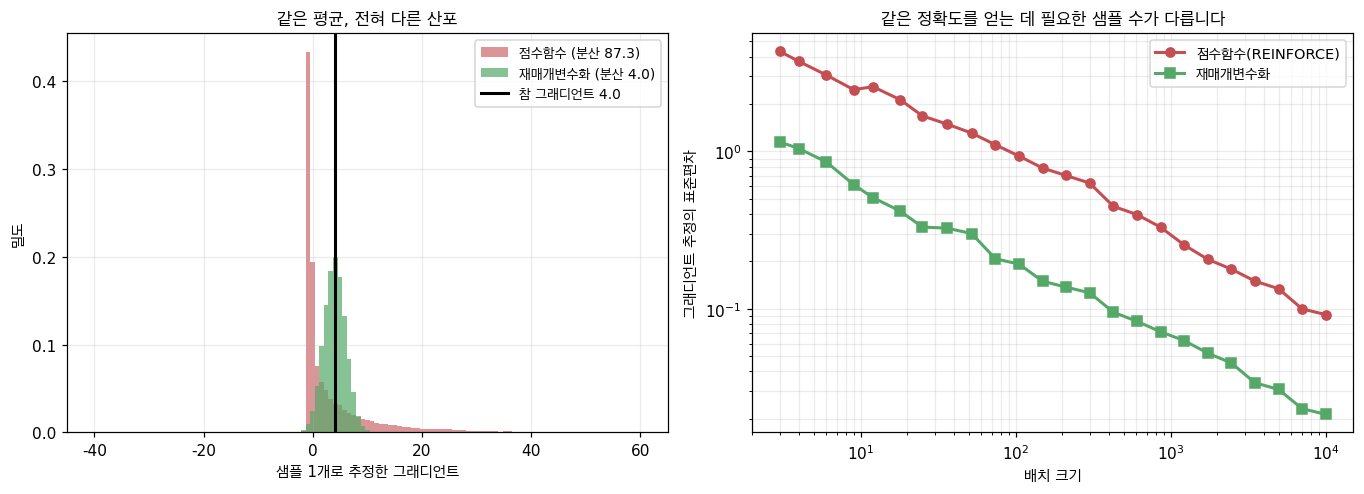

평균적으로 점수함수 추정량의 표준편차가 4.5배 큽니다.
분산은 그 제곱이니, 같은 정밀도를 얻으려면 샘플이 약 20배 필요합니다.

💡 그래서 미분 가능한 경우에는 항상 재매개변수화를 씁니다 (VAE, 디퓨전).
   이산 선택처럼 미분이 안 되는 경우에만 REINFORCE나 11절의 Gumbel-Softmax로 갑니다.


In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))

sf_all = score_function_grad(60_000, 5)
rp_all = reparam_grad(60_000, 5)
bins = np.linspace(-40, 60, 120)
ax1.hist(sf_all, bins=bins, alpha=0.6, color="#c44e52", density=True,
         label=f"점수함수 (분산 {sf_all.var():.1f})")
ax1.hist(rp_all, bins=bins, alpha=0.7, color="#55a868", density=True,
         label=f"재매개변수화 (분산 {rp_all.var():.1f})")
ax1.axvline(TRUE_GRAD, color="black", lw=2, label=f"참 그래디언트 {TRUE_GRAD}")
ax1.set_xlabel("샘플 1개로 추정한 그래디언트"); ax1.set_ylabel("밀도")
ax1.set_title("같은 평균, 전혀 다른 산포", fontsize=11.5)
ax1.legend(fontsize=9); ax1.grid(alpha=0.25)

ns = np.unique(np.logspace(0.5, 4, 24).astype(int))
sf_se, rp_se = [], []
for n in ns:
    sf_batch = [score_function_grad(int(n), s).mean() for s in range(60)]
    rp_batch = [reparam_grad(int(n), s).mean() for s in range(60)]
    sf_se.append(np.std(sf_batch))
    rp_se.append(np.std(rp_batch))
ax2.loglog(ns, sf_se, "o-", color="#c44e52", lw=2, label="점수함수(REINFORCE)")
ax2.loglog(ns, rp_se, "s-", color="#55a868", lw=2, label="재매개변수화")
ax2.set_xlabel("배치 크기"); ax2.set_ylabel("그래디언트 추정의 표준편차")
ax2.set_title("같은 정확도를 얻는 데 필요한 샘플 수가 다릅니다", fontsize=11.5)
ax2.legend(fontsize=9.5); ax2.grid(alpha=0.25, which="both")

plt.tight_layout()
plt.show()

ratio = np.mean(np.array(sf_se) / np.array(rp_se))
print(f"평균적으로 점수함수 추정량의 표준편차가 {ratio:.1f}배 큽니다.")
print(f"분산은 그 제곱이니, 같은 정밀도를 얻으려면 샘플이 약 {ratio**2:.0f}배 필요합니다.")
print("\n💡 그래서 미분 가능한 경우에는 항상 재매개변수화를 씁니다 (VAE, 디퓨전).")
print("   이산 선택처럼 미분이 안 되는 경우에만 REINFORCE나 11절의 Gumbel-Softmax로 갑니다.")

## 1️⃣1️⃣ Gumbel-Softmax — 이산 선택을 미분 가능하게

재매개변수화 트릭은 **연속 분포(가우시안)** 에서 작동합니다.
그런데 **범주형 분포**는요? "10개 중 3번을 골랐다"를 어떻게 미분할까요?

### 📐 먼저 Gumbel-Max 트릭 (미분 불가능하지만 정확함)

놀랍도록 예쁜 사실이 하나 있습니다.

```
로그 확률 log(p_1), ..., log(p_k) 를 가진 범주형 분포에서 뽑으려면:
  1. 각 범주마다 g_i ~ Gumbel(0, 1) 을 뽑는다
     (g = -log(-log(u)),  u ~ Uniform(0,1))
  2. argmax(log(p_i) + g_i) 를 반환한다

이렇게 하면 정확히 범주형 분포에서 뽑은 것과 같습니다.
```

즉 **"로그 확률에 검블 노이즈를 더하고 최댓값을 고르는 것"** 이 곧 범주형 샘플링입니다.
무작위성이 `g`라는 **파라미터와 무관한 노이즈**로 분리됐다는 점에 주목하세요.
재매개변수화 트릭과 정확히 같은 구조입니다.

### 📐 그런데 argmax가 미분이 안 됩니다

그래서 **argmax를 softmax로 부드럽게 바꿉니다.**

$$y_i = \frac{\exp((\log p_i + g_i)/\tau)}{\sum_j \exp((\log p_j + g_j)/\tau)}$$

`τ`(온도)가 근사의 정도를 조절합니다.

```
τ → 0   : 원-핫 벡터에 가까워짐 (진짜 범주형에 가깝지만 그래디언트가 불안정)
τ → ∞   : 균등분포 (1/k, ..., 1/k)
τ = 1.0 : 부드러운 근사
```

출력은 **하드 원-핫이 아니라 소프트 원-핫**(확률 벡터)입니다. 대신 softmax를 통해 그래디언트가 흐릅니다.

학습할 때는 흔히 **straight-through 추정량**을 씁니다.
순전파에서는 하드 argmax를 쓰고, 역전파에서는 소프트 Gumbel-Softmax의 그래디언트를 쓰는 거죠.

### 🏭 어디에 쓰이나

VAE의 이산 잠재변수 · 신경망 구조 탐색(이산 연산 선택) · 하드 어텐션 · 이산 행동 강화학습

In [23]:
def gumbel_noise():
    u = random.random()
    return -math.log(-math.log(u + 1e-20) + 1e-20)

def gumbel_max_sample(probs):
    scores = [math.log(p + 1e-20) + gumbel_noise() for p in probs]
    return max(range(len(scores)), key=lambda i: scores[i])

def gumbel_softmax(probs, tau):
    scores = [(math.log(p + 1e-20) + gumbel_noise()) / tau for p in probs]
    return softmax(scores)

target = [0.5, 0.3, 0.15, 0.05]

print("[1] Gumbel-Max가 정말 범주형 샘플링과 같은가?")
random.seed(23)
counts = Counter(gumbel_max_sample(target) for _ in range(200_000))
print(f"  목표 확률       : {target}")
print(f"  Gumbel-Max 빈도 : {[round(counts[i]/200_000, 4) for i in range(4)]}")
random.seed(23)
counts2 = Counter(sample_categorical(target) for _ in range(200_000))
print(f"  누적합 방식 빈도 : {[round(counts2[i]/200_000, 4) for i in range(4)]}")
print("  => 완전히 같은 분포입니다. 그런데 Gumbel 쪽은 노이즈가 분리되어 있습니다.")

print("\n[2] τ를 낮추면 원-핫에 가까워집니다")
print("    (단발 샘플 하나는 운에 좌우되므로 2,000번 뽑아 평균을 냅니다)")
print(f"{'τ':>8}{'평균 최댓값':>14}{'평균 엔트로피':>16}   샘플 하나 예시")
print("-" * 78)
for tau in [5.0, 2.0, 1.0, 0.5, 0.1]:
    random.seed(31)
    ys = [gumbel_softmax(target, tau) for _ in range(2000)]
    avg_max = float(np.mean([max(y) for y in ys]))
    avg_ent = float(np.mean([-sum(v * math.log2(v) for v in y if v > 0) for y in ys]))
    vec = "[" + ", ".join(f"{v:.3f}" for v in ys[0]) + "]"
    print(f"{tau:>8.1f}{avg_max:>14.3f}{avg_ent:>16.4f}   {vec}")
print(f"\n(완벽한 원-핫이면 최댓값 1·엔트로피 0, 균등이면 최댓값 0.25·엔트로피 {math.log2(4):.1f})")

print("\n[3] τ가 작아도 '평균적으로는' 목표 분포를 지킵니다")
for tau in [2.0, 1.0, 0.3]:
    random.seed(41)
    avg = np.mean([gumbel_softmax(target, tau) for _ in range(50_000)], axis=0)
    print(f"  τ={tau:<4}: 기댓값 {np.round(avg, 4)}  (목표 {target})")
print("  => τ가 클수록 목표에서 벗어납니다. 정확도와 그래디언트 안정성 사이의 트레이드오프입니다.")

[1] Gumbel-Max가 정말 범주형 샘플링과 같은가?
  목표 확률       : [0.5, 0.3, 0.15, 0.05]
  Gumbel-Max 빈도 : [0.4989, 0.3001, 0.1508, 0.0502]
  누적합 방식 빈도 : [0.4989, 0.2998, 0.1508, 0.0505]
  => 완전히 같은 분포입니다. 그런데 Gumbel 쪽은 노이즈가 분리되어 있습니다.

[2] τ를 낮추면 원-핫에 가까워집니다
    (단발 샘플 하나는 운에 좌우되므로 2,000번 뽑아 평균을 냅니다)
       τ        평균 최댓값         평균 엔트로피   샘플 하나 예시
------------------------------------------------------------------------------
     5.0         0.343          1.9415   [0.242, 0.251, 0.259, 0.249]
     2.0         0.481          1.6973   [0.229, 0.252, 0.272, 0.247]
     1.0         0.644          1.2520   [0.209, 0.253, 0.296, 0.242]
     0.5         0.797          0.7357   [0.173, 0.252, 0.344, 0.231]
     0.1         0.960          0.1408   [0.023, 0.152, 0.726, 0.099]

(완벽한 원-핫이면 최댓값 1·엔트로피 0, 균등이면 최댓값 0.25·엔트로피 2.0)

[3] τ가 작아도 '평균적으로는' 목표 분포를 지킵니다
  τ=2.0 : 기댓값 [0.366  0.2912 0.213  0.1299]  (목표 [0.5, 0.3, 0.15, 0.05])
  τ=1.0 : 기댓값 [0.4308 0.3024 0.1839 0.083 ]  (목표 [0.5, 0.3, 0.15, 0.05])
  τ=0.

### 🖼️ 그림 10 — τ가 만드는 '부드러움'의 정도

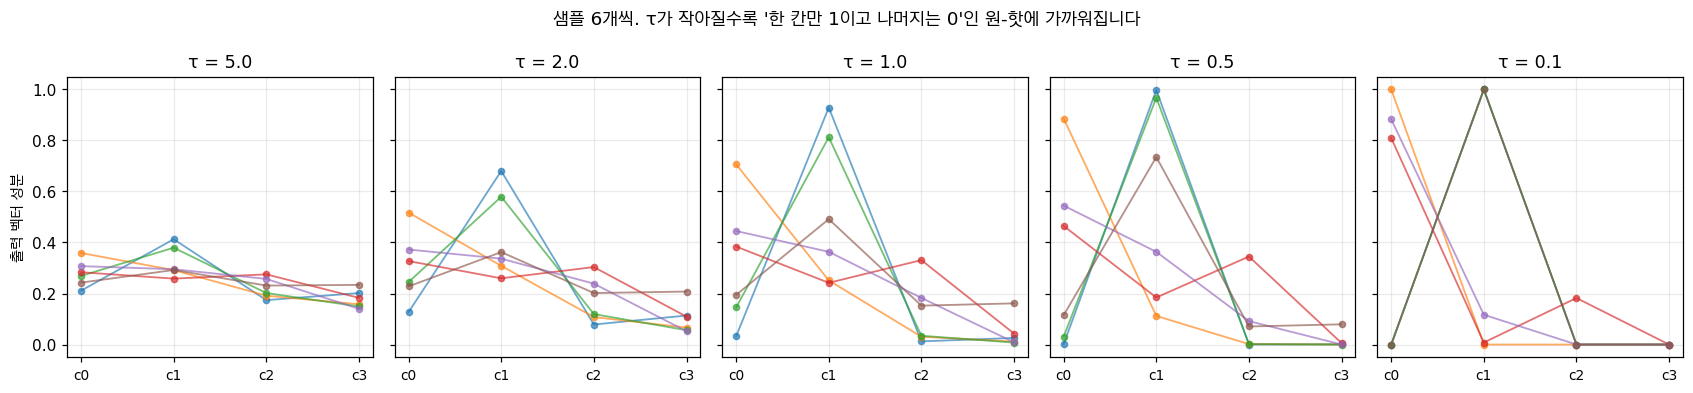

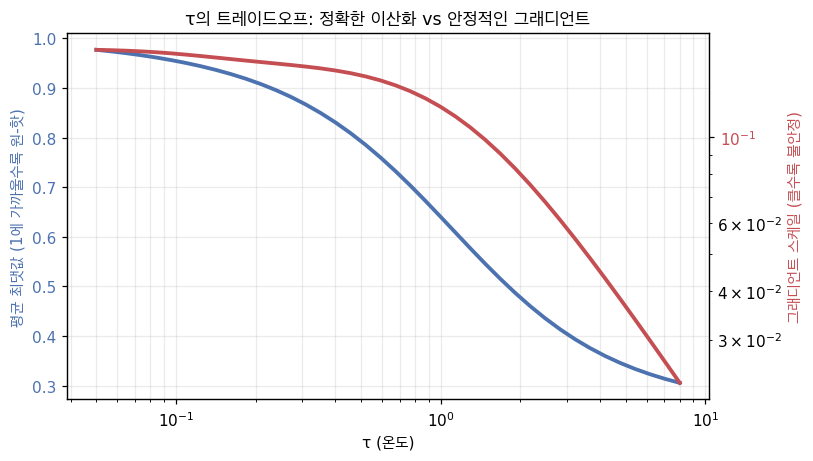

파란 선: τ를 낮추면 진짜 범주형 샘플에 가까워집니다 (좋음)
빨간 선: 그런데 그래디언트 크기가 1/τ로 폭발합니다 (나쁨)

💡 그래서 실무에서는 τ를 1.0 근처에서 시작해 학습 중에 서서히 낮춥니다(annealing).
   초반에는 안정적으로 배우고, 후반에는 진짜 이산 선택에 가깝게 만드는 거죠.


In [24]:
fig, axes = plt.subplots(1, 5, figsize=(15.5, 3.6), sharey=True)
taus = [5.0, 2.0, 1.0, 0.5, 0.1]
for ax, tau in zip(axes, taus):
    random.seed(55)
    samples_y = [gumbel_softmax(target, tau) for _ in range(6)]
    x = np.arange(len(target))
    for k, y in enumerate(samples_y):
        ax.plot(x, y, "o-", ms=4, lw=1.2, alpha=0.65)
    ax.set_title(f"τ = {tau}", fontsize=11.5)
    ax.set_xticks(x); ax.set_xticklabels([f"c{i}" for i in x], fontsize=9)
    ax.set_ylim(-0.05, 1.05); ax.grid(alpha=0.25)
axes[0].set_ylabel("출력 벡터 성분")
plt.suptitle("샘플 6개씩. τ가 작아질수록 '한 칸만 1이고 나머지는 0'인 원-핫에 가까워집니다",
             fontsize=12)
plt.tight_layout()
plt.show()

# τ에 따른 원-핫 근접도와 그래디언트 크기의 트레이드오프
taus_fine = np.logspace(np.log10(0.05), np.log10(8), 40)
onehot_score, grad_scale = [], []
for tau in taus_fine:
    random.seed(61)
    ys = np.array([gumbel_softmax(target, float(tau)) for _ in range(3000)])
    onehot_score.append(ys.max(axis=1).mean())
    # softmax 야코비안의 크기 ~ (1/τ)·p(1-p) 로 스케일합니다
    grad_scale.append(float(np.mean(ys * (1 - ys)) / tau))

fig, ax1 = plt.subplots(figsize=(7.5, 4.3))
ax1.semilogx(taus_fine, onehot_score, lw=2.5, color="#4c72b0")
ax1.set_xlabel("τ (온도)"); ax1.set_ylabel("평균 최댓값 (1에 가까울수록 원-핫)", color="#4c72b0")
ax1.tick_params(axis="y", labelcolor="#4c72b0")
ax1.grid(alpha=0.25, which="both")
ax2 = ax1.twinx()
ax2.loglog(taus_fine, grad_scale, lw=2.5, color="#c44e52")
ax2.set_ylabel("그래디언트 스케일 (클수록 불안정)", color="#c44e52")
ax2.tick_params(axis="y", labelcolor="#c44e52")
ax1.set_title("τ의 트레이드오프: 정확한 이산화 vs 안정적인 그래디언트", fontsize=11.5)
plt.tight_layout()
plt.show()

print("파란 선: τ를 낮추면 진짜 범주형 샘플에 가까워집니다 (좋음)")
print("빨간 선: 그런데 그래디언트 크기가 1/τ로 폭발합니다 (나쁨)")
print("\n💡 그래서 실무에서는 τ를 1.0 근처에서 시작해 학습 중에 서서히 낮춥니다(annealing).")
print("   초반에는 안정적으로 배우고, 후반에는 진짜 이산 선택에 가깝게 만드는 거죠.")

## 1️⃣2️⃣ 층화 샘플링 — 공짜로 분산 줄이기

몬테카를로의 `1/√N` 수렴은 느립니다. 조금이라도 개선할 방법이 없을까요?

문제 하나를 짚어 봅시다. **균등하게 무작위로 뽑으면 우연히 뭉치거나 빈틈이 생깁니다.**
[0,1]에서 10개를 뽑았는데 전부 왼쪽 절반에 몰릴 수도 있어요. 확률이 낮을 뿐 가능합니다.

**층화 샘플링**은 공간을 나누고 **각 구획에서 하나씩** 뽑아 이런 우연을 원천 차단합니다.

```
표준 몬테카를로:
  [0,1]에서 N개를 그냥 뽑는다 → 뭉침과 빈틈이 생길 수 있다

층화 샘플링:
  [0,1]을 N개의 층으로 나눈다: [0,1/N), [1/N,2/N), ...
  각 층 안에서 하나씩 뽑는다
  x_i = (i + u_i) / N,   u_i ~ Uniform(0,1),  i = 0,...,N-1
```

### 🔑 그리고 이건 **항상** 이득입니다

$$\text{Var}(\text{층화}) \le \text{Var}(\text{표준 몬테카를로})$$

부등호가 아니라 **부등호 또는 등호**입니다. 절대 손해 보지 않아요.
개선 폭은 `f(x)`가 매끄럽게 변할수록 큽니다. 구간별 상수 함수라면 **층화가 정확한 값**을 줍니다.

### 🏭 어디에 쓰이나

- 수치 적분 (준몬테카를로)
- **학습 데이터 분할** — 각 폴드의 클래스 비율을 맞추는 `StratifiedKFold`가 바로 이겁니다
- 층화를 결합한 중요도 샘플링
- **NeRF** — 카메라 광선을 따라 샘플 점을 층화해서 배치합니다

In [25]:
def mc_integrate(f, n, seed):
    rng = np.random.default_rng(seed)
    return float(np.mean(f(rng.uniform(0, 1, n))))

def stratified_integrate(f, n, seed):
    rng = np.random.default_rng(seed)
    i = np.arange(n)
    xs = (i + rng.uniform(0, 1, n)) / n        # 각 층에서 하나씩
    return float(np.mean(f(xs)))

tests = [
    ("f(x) = x                 (선형)", lambda x: x, 0.5),
    ("f(x) = sin(πx)           (매끄러움)", lambda x: np.sin(np.pi * x), 2 / math.pi),
    ("f(x) = x < 0.5 ? 1 : 0   (계단)", lambda x: (x < 0.5).astype(float), 0.5),
    ("f(x) = sin(40πx)²        (진동 심함)", lambda x: np.sin(40 * np.pi * x) ** 2, 0.5),
]

N_INT, TRIALS = 200, 2000
print(f"[0,1] 구간 적분을 N={N_INT}개 샘플로 {TRIALS}번씩 추정하고, 추정값의 표준편차를 비교합니다\n")
print(f"{'피적분 함수':<36}{'MC 표준편차':>16}{'층화 표준편차':>18}{'분산 감소':>14}")
print("-" * 86)
for name, f, true_val in tests:
    mc = np.array([mc_integrate(f, N_INT, s) for s in range(TRIALS)])
    st = np.array([stratified_integrate(f, N_INT, s) for s in range(TRIALS)])
    ratio = mc.var() / st.var() if st.var() > 0 else float("inf")
    ratio_s = f"{ratio:,.1f}배" if math.isfinite(ratio) else "∞"
    print(f"{name:<36}{mc.std():>16.6f}{st.std():>18.6f}{ratio_s:>14}")

print("\n=> 매끄러운 함수일수록 이득이 큽니다.")
print("   진동이 심한 함수에서는 이득이 작습니다 — 층 안에서도 함수가 많이 변하니까요.")
print("   중요한 건 '어떤 경우에도 손해는 없다'는 점입니다.")

[0,1] 구간 적분을 N=200개 샘플로 2000번씩 추정하고, 추정값의 표준편차를 비교합니다

피적분 함수                                       MC 표준편차           층화 표준편차         분산 감소
--------------------------------------------------------------------------------------
f(x) = x                 (선형)               0.020530          0.000103     40,000.0배
f(x) = sin(πx)           (매끄러움)             0.021562          0.000226      9,067.5배
f(x) = x < 0.5 ? 1 : 0   (계단)               0.035620          0.000000             ∞
f(x) = sin(40πx)²        (진동 심함)            0.024731          0.008825          7.9배

=> 매끄러운 함수일수록 이득이 큽니다.
   진동이 심한 함수에서는 이득이 작습니다 — 층 안에서도 함수가 많이 변하니까요.
   중요한 건 '어떤 경우에도 손해는 없다'는 점입니다.


### 🖼️ 그림 11 — 뭉침과 빈틈 vs 고른 배치

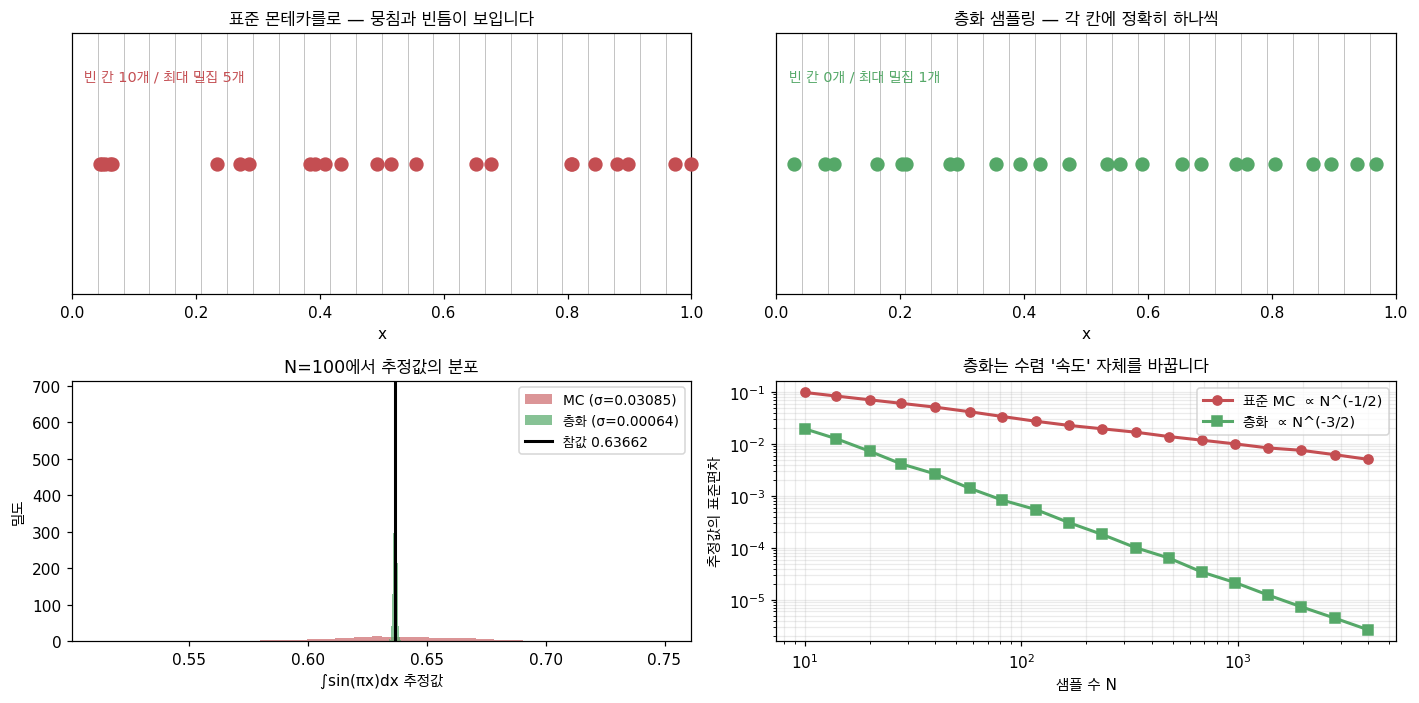

로그-로그 기울기: 표준 MC -0.496,  층화 -1.496

표준 MC는 -0.5(즉 1/√N)인데, 매끄러운 1차원 함수에서 층화는 -1.5까지 나옵니다.
이건 상수배 개선이 아니라 '수렴 차수'가 달라진 것입니다. 층화가 공짜 점심인 이유예요.


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6.5))

rng = np.random.default_rng(5)
n_show = 24
mc_pts = rng.uniform(0, 1, n_show)
i = np.arange(n_show)
st_pts = (i + rng.uniform(0, 1, n_show)) / n_show

for ax, pts, title, color in [
    (axes[0][0], mc_pts, "표준 몬테카를로 — 뭉침과 빈틈이 보입니다", "#c44e52"),
    (axes[0][1], st_pts, "층화 샘플링 — 각 칸에 정확히 하나씩", "#55a868"),
]:
    ax.scatter(pts, np.zeros_like(pts), s=70, color=color, zorder=5, clip_on=False)
    for b in np.linspace(0, 1, n_show + 1):
        ax.axvline(b, color="gray", lw=0.6, alpha=0.5)
    ax.set_ylim(-0.5, 0.5); ax.set_xlim(0, 1)
    ax.set_yticks([])
    ax.set_title(title, fontsize=11.5)
    ax.set_xlabel("x")
    # 빈 칸 표시
    counts = np.histogram(pts, bins=np.linspace(0, 1, n_show + 1))[0]
    empty = int((counts == 0).sum())
    ax.text(0.02, 0.32, f"빈 칸 {empty}개 / 최대 밀집 {counts.max()}개", fontsize=9.5, color=color)

# 추정치 분포 비교
f = lambda x: np.sin(np.pi * x)
true_val = 2 / math.pi
mc = np.array([mc_integrate(f, 100, s) for s in range(4000)])
st = np.array([stratified_integrate(f, 100, s) for s in range(4000)])
ax = axes[1][0]
ax.hist(mc, bins=60, alpha=0.6, color="#c44e52", density=True, label=f"MC (σ={mc.std():.5f})")
ax.hist(st, bins=60, alpha=0.7, color="#55a868", density=True, label=f"층화 (σ={st.std():.5f})")
ax.axvline(true_val, color="black", lw=2, label=f"참값 {true_val:.5f}")
ax.set_xlabel("∫sin(πx)dx 추정값"); ax.set_ylabel("밀도")
ax.set_title("N=100에서 추정값의 분포", fontsize=11.5)
ax.legend(fontsize=9)

# 수렴 속도 비교
ns = np.unique(np.logspace(1, 3.6, 18).astype(int))
mc_sd, st_sd = [], []
for n in ns:
    mc_sd.append(np.std([mc_integrate(f, int(n), s) for s in range(400)]))
    st_sd.append(np.std([stratified_integrate(f, int(n), s) for s in range(400)]))
ax = axes[1][1]
ax.loglog(ns, mc_sd, "o-", color="#c44e52", lw=2, label="표준 MC  ∝ N^(-1/2)")
ax.loglog(ns, st_sd, "s-", color="#55a868", lw=2, label="층화  ∝ N^(-3/2)")
ax.set_xlabel("샘플 수 N"); ax.set_ylabel("추정값의 표준편차")
ax.set_title("층화는 수렴 '속도' 자체를 바꿉니다", fontsize=11.5)
ax.legend(fontsize=9.5); ax.grid(alpha=0.25, which="both")

plt.tight_layout()
plt.show()

s_mc = np.polyfit(np.log(ns), np.log(mc_sd), 1)[0]
s_st = np.polyfit(np.log(ns), np.log(st_sd), 1)[0]
print(f"로그-로그 기울기: 표준 MC {s_mc:.3f},  층화 {s_st:.3f}")
print("\n표준 MC는 -0.5(즉 1/√N)인데, 매끄러운 1차원 함수에서 층화는 -1.5까지 나옵니다.")
print("이건 상수배 개선이 아니라 '수렴 차수'가 달라진 것입니다. 층화가 공짜 점심인 이유예요.")

## 1️⃣3️⃣ 디퓨전 모델과의 연결 — 이 모든 게 어디서 만나는가

디퓨전 모델은 이번 레슨에서 배운 거의 모든 조각이 한자리에 모이는 곳입니다.

**순방향 과정(알려져 있음)**: 이미지에 T 스텝에 걸쳐 가우시안 노이즈를 더해 순수 노이즈로 만듭니다.

$$x_t = \sqrt{\alpha_t}\,x_{t-1} + \sqrt{1-\alpha_t}\,\varepsilon, \qquad \varepsilon \sim N(0,I)$$

T 스텝 뒤에는 `x_T ~ N(0, I)`, 즉 완전한 노이즈가 됩니다.

**역방향 과정(학습됨)**: 노이즈에서 시작해 한 스텝씩 노이즈를 제거합니다.
**그리고 각 디노이징 스텝이 곧 하나의 샘플링 스텝입니다.**

### 🔑 이번 레슨의 도구들이 어디에 있나

| 이번에 배운 것 | 디퓨전에서의 역할 |
| --- | --- |
| **재매개변수화 트릭** (10절) | 각 디노이징 스텝이 `노이즈 뽑기 + 결정론적 변환`입니다 |
| **temperature** (8절) | 노이즈 스케줄 `{α_t}`가 일종의 온도 어닐링입니다 |
| **몬테카를로 추정** (5절) | ELBO를 근사할 때 씁니다 |
| **마르코프 연쇄** (6절) | 조상 샘플링(ancestral sampling) — 각 스텝은 현재 상태에만 의존합니다 |

> **이미지 생성 전체가 결국 반복적인 샘플링입니다.**
> 노이즈에서 출발해서, 매 스텝마다 학습된 디노이징 모델을 조건으로 삼아
> 조금 덜 노이즈한 버전을 샘플링하는 것. 그게 전부예요.

아래에서 순방향 과정만 1차원 신호로 직접 돌려 보겠습니다.
(역방향은 학습된 모델이 필요하니 여기서는 다루지 않습니다.)

In [27]:
# 순방향 확산을 1D 신호에서 직접 돌려 봅니다
rng = np.random.default_rng(0)
T = 200
betas = np.linspace(1e-4, 0.02, T)          # DDPM의 선형 노이즈 스케줄
alphas = 1.0 - betas
alpha_bars = np.cumprod(alphas)

t_axis = np.linspace(0, 4 * np.pi, 300)
x0 = np.sin(t_axis) + 0.4 * np.sin(3 * t_axis)      # 원본 '이미지'(여기서는 신호)

def forward_diffuse(x0, t, rng):
    # 닫힌 형태: x_t = √(ᾱ_t)·x_0 + √(1-ᾱ_t)·ε   (한 번에 t 스텝 점프)
    ab = alpha_bars[t]
    eps = rng.normal(size=x0.shape)
    return math.sqrt(ab) * x0 + math.sqrt(1 - ab) * eps

print("순방향 확산 — 신호가 노이즈에 잠기는 과정")
print(f"{'스텝 t':>8}{'ᾱ_t':>12}{'신호 비중 √ᾱ':>16}{'노이즈 비중 √(1-ᾱ)':>22}{'원본과의 상관':>16}")
print("-" * 76)
for t in [0, 20, 50, 100, 150, 199]:
    xt = forward_diffuse(x0, t, np.random.default_rng(1))
    corr = float(np.corrcoef(x0, xt)[0, 1])
    print(f"{t:>8}{alpha_bars[t]:>12.5f}{math.sqrt(alpha_bars[t]):>16.4f}"
          f"{math.sqrt(1-alpha_bars[t]):>22.4f}{corr:>16.4f}")

print("\n=> t가 커질수록 원본의 흔적이 사라지고 순수 노이즈에 가까워집니다.")
print("   그리고 이 각 스텝은 정확히 '재매개변수화된 가우시안 샘플링'입니다:")
print("     x_t = (결정론적 변환) + (스케일) × ε,   ε ~ N(0, I)")
print("   10절에서 본 z = μ + σ·ε 와 완전히 같은 구조라는 점을 확인하세요.")

순방향 확산 — 신호가 노이즈에 잠기는 과정
    스텝 t         ᾱ_t        신호 비중 √ᾱ         노이즈 비중 √(1-ᾱ)         원본과의 상관
----------------------------------------------------------------------------
       0     0.99990          0.9999                0.0100          0.9999
      20     0.97715          0.9885                0.1512          0.9836
      50     0.87562          0.9357                0.3527          0.9130
     100     0.59640          0.7723                0.6353          0.7244
     150     0.31555          0.5617                0.8273          0.5193
     199     0.13218          0.3636                0.9316          0.3464

=> t가 커질수록 원본의 흔적이 사라지고 순수 노이즈에 가까워집니다.
   그리고 이 각 스텝은 정확히 '재매개변수화된 가우시안 샘플링'입니다:
     x_t = (결정론적 변환) + (스케일) × ε,   ε ~ N(0, I)
   10절에서 본 z = μ + σ·ε 와 완전히 같은 구조라는 점을 확인하세요.


### 🖼️ 그림 12 — 순방향 확산: 신호가 노이즈가 되는 길

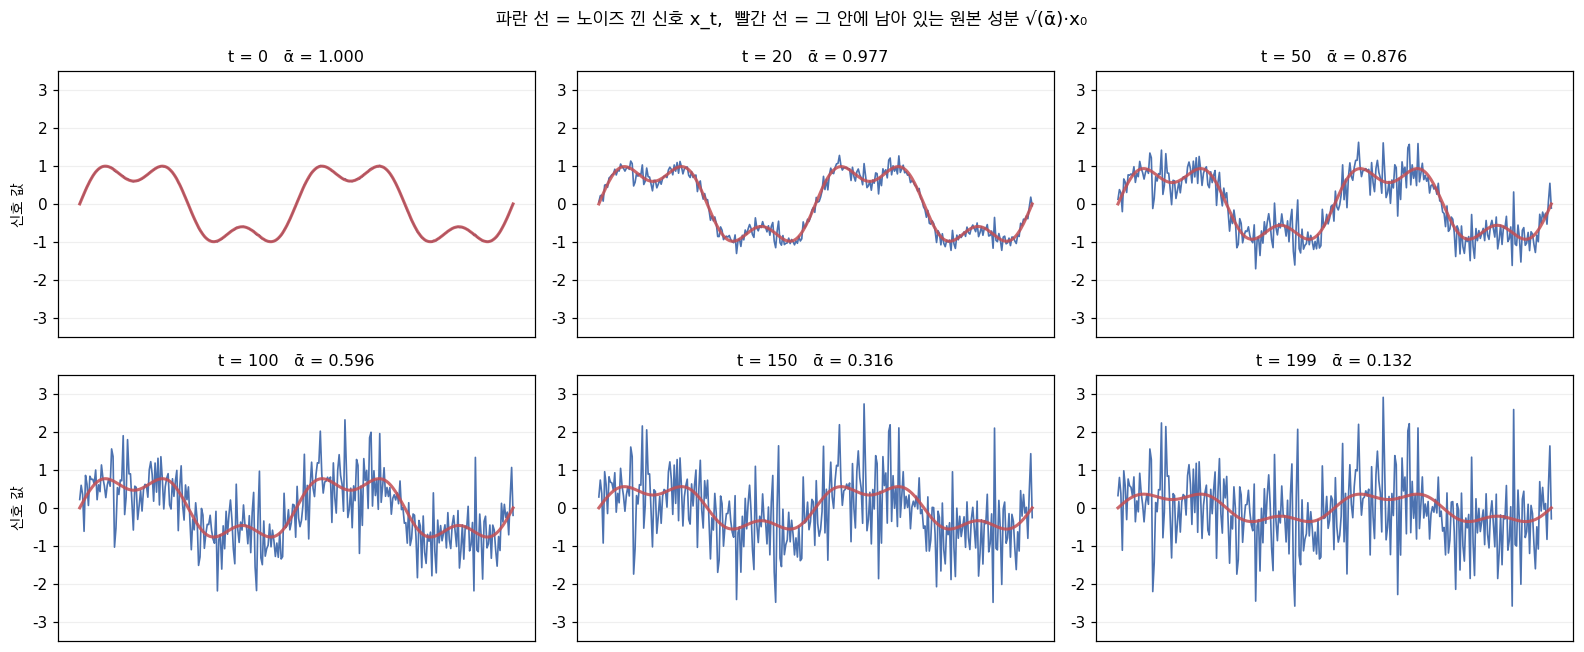

역방향 과정(생성)은 오른쪽 아래에서 시작해 왼쪽 위로 거슬러 올라가는 것입니다.
모델이 학습하는 건 '이 노이즈 중 어느 부분이 ε이었나'를 맞히는 일이고,
그걸 알면 한 스텝 되돌릴 수 있습니다. 그 되돌리기 한 번이 곧 샘플링 한 번입니다.


In [28]:
fig, axes = plt.subplots(2, 3, figsize=(14.5, 6))
steps = [0, 20, 50, 100, 150, 199]
for ax, t in zip(axes.ravel(), steps):
    xt = forward_diffuse(x0, t, np.random.default_rng(1))
    ax.plot(t_axis, xt, lw=1.1, color="#4c72b0")
    ax.plot(t_axis, math.sqrt(alpha_bars[t]) * x0, lw=2, color="#c44e52", alpha=0.85)
    ax.set_title(f"t = {t}   ᾱ = {alpha_bars[t]:.3f}", fontsize=10.5)
    ax.set_ylim(-3.5, 3.5)
    ax.set_xticks([])
    ax.grid(alpha=0.2)
axes[0][0].set_ylabel("신호 값")
axes[1][0].set_ylabel("신호 값")
plt.suptitle("파란 선 = 노이즈 낀 신호 x_t,  빨간 선 = 그 안에 남아 있는 원본 성분 √(ᾱ)·x₀",
             fontsize=12)
plt.tight_layout()
plt.show()

print("역방향 과정(생성)은 오른쪽 아래에서 시작해 왼쪽 위로 거슬러 올라가는 것입니다.")
print("모델이 학습하는 건 '이 노이즈 중 어느 부분이 ε이었나'를 맞히는 일이고,")
print("그걸 알면 한 스텝 되돌릴 수 있습니다. 그 되돌리기 한 번이 곧 샘플링 한 번입니다.")

## 1️⃣4️⃣ 📝 연습문제 (풀이 포함)

원문의 5문제를 그대로 풀어 봅니다.

1. **코시 분포 역변환 샘플링** — CDF는 `F(x) = 0.5 + arctan(x)/π`. 1만 개 뽑아 진짜 PDF와 비교하고 **두꺼운 꼬리**를 확인하기.
2. **Beta(2,5) 기각 샘플링** — Uniform(0,1) 제안으로 샘플링하고 이론 수용률 구하기.
3. **∫₀^π sin(x)dx 몬테카를로** — N = 1천/1만/10만에서 오차를 비교하고 `O(1/√N)` 확인하기.
4. **2D Metropolis-Hastings** — `p(x,y) ∝ exp(-(x²y² + x² + y² - 8x - 8y)/2)` 에서 샘플링하고 제안 폭을 바꿔 보기.
5. **텍스트 생성 데모** — 어휘 10개로 20토큰짜리 시퀀스를 (a)탐욕 (b)T=0.7 (c)top-k=3 (d)top-p=0.9 로 생성하고 다양성 비교하기.

In [29]:
print("=" * 74)
print("연습 1 — 코시 분포 역변환 샘플링 (두꺼운 꼬리 체험)")
print("=" * 74)
random.seed(101)
cauchy = [sample_cauchy_inverse_cdf() for _ in range(10_000)]
normal_ref = [random.gauss(0, 1) for _ in range(10_000)]

print(f"{'통계량':<20}{'코시':>18}{'표준정규(비교용)':>20}")
print("-" * 58)
print(f"{'중앙값':<20}{np.median(cauchy):>18.4f}{np.median(normal_ref):>20.4f}")
print(f"{'평균':<20}{np.mean(cauchy):>18.4f}{np.mean(normal_ref):>20.4f}")
print(f"{'표준편차':<20}{np.std(cauchy):>18.4f}{np.std(normal_ref):>20.4f}")
print(f"{'최댓값 |x|':<20}{np.max(np.abs(cauchy)):>18.4f}{np.max(np.abs(normal_ref)):>20.4f}")
print(f"{'|x| > 10 개수':<20}{int(np.sum(np.abs(cauchy) > 10)):>18,}{int(np.sum(np.abs(normal_ref) > 10)):>20,}")

print("\n💡 코시 분포는 평균과 분산이 '정의되지 않습니다'.")
print("   표본을 늘려도 표본평균이 수렴하지 않습니다 (6주차 통계 노트북의 CLT 반례와 같은 분포입니다).")
print(f"   중앙값은 안정적입니다: 여러 시드에서 {[round(np.median([sample_cauchy_inverse_cdf() for _ in range(10_000)]),3) for _ in range(5)]}")

연습 1 — 코시 분포 역변환 샘플링 (두꺼운 꼬리 체험)
통계량                                 코시           표준정규(비교용)
----------------------------------------------------------
중앙값                             0.0313             -0.0038
평균                             -0.3966             -0.0070
표준편차                           42.7035              1.0083
최댓값 |x|                      2280.7958              3.7485
|x| > 10 개수                        628                   0

💡 코시 분포는 평균과 분산이 '정의되지 않습니다'.
   표본을 늘려도 표본평균이 수렴하지 않습니다 (6주차 통계 노트북의 CLT 반례와 같은 분포입니다).
   중앙값은 안정적입니다: 여러 시드에서 [-0.012, 0.013, 0.02, -0.026, 0.008]


In [30]:
print("=" * 74)
print("연습 2 — Beta(2,5) 기각 샘플링")
print("=" * 74)

def beta_pdf(x, a=2, b=5):
    if x <= 0 or x >= 1:
        return 0.0
    log_B = math.lgamma(a) + math.lgamma(b) - math.lgamma(a + b)
    return math.exp((a - 1) * math.log(x) + (b - 1) * math.log(1 - x) - log_B)

# 최빈값(mode) = (a-1)/(a+b-2) 에서 PDF가 최대입니다
mode = (2 - 1) / (2 + 5 - 2)
M_beta = beta_pdf(mode)
print(f"Beta(2,5)의 최빈값 x* = {mode:.4f},  거기서의 밀도 = {M_beta:.4f}")
print(f"제안이 Uniform(0,1)이므로 q(x)=1  ->  M = {M_beta:.4f}")
print(f"이론 수용률 = 1/M = {1/M_beta:.4f}")

random.seed(102)
beta_samples, total_tries = [], 0
for _ in range(30_000):
    x, t = rejection_sample(beta_pdf, lambda: random.random(), lambda x: 1.0, M_beta)
    beta_samples.append(x)
    total_tries += t

print(f"\n실제 수용률 = {len(beta_samples)/total_tries:.4f}")
print(f"표본 평균   = {np.mean(beta_samples):.4f}   이론값 a/(a+b) = {2/7:.4f}")
print(f"표본 분산   = {np.var(beta_samples):.5f}   이론값 = {2*5/((7**2)*(8)):.5f}")

연습 2 — Beta(2,5) 기각 샘플링
Beta(2,5)의 최빈값 x* = 0.2000,  거기서의 밀도 = 2.4576
제안이 Uniform(0,1)이므로 q(x)=1  ->  M = 2.4576
이론 수용률 = 1/M = 0.4069

실제 수용률 = 0.4089
표본 평균   = 0.2873   이론값 a/(a+b) = 0.2857
표본 분산   = 0.02542   이론값 = 0.02551


In [31]:
print("=" * 74)
print("연습 3 — ∫₀^π sin(x)dx 를 몬테카를로로 (정답 = 2)")
print("=" * 74)

def mc_sin_integral(n, seed):
    rng = np.random.default_rng(seed)
    xs = rng.uniform(0, math.pi, n)
    return float(math.pi * np.mean(np.sin(xs)))     # (구간 길이) × (평균값)

TRUE = 2.0
print(f"{'N':>12}{'추정값':>14}{'절대 오차':>14}{'1/√N':>14}{'오차/(1/√N)':>16}")
print("-" * 72)
for n in [1_000, 10_000, 100_000, 1_000_000]:
    errs = [abs(mc_sin_integral(n, s) - TRUE) for s in range(200)]
    e = float(np.mean(errs))
    print(f"{n:>12,}{mc_sin_integral(n, 0):>14.6f}{e:>14.6f}{1/math.sqrt(n):>14.6f}{e*math.sqrt(n):>16.4f}")

print("\n=> 마지막 열(오차 × √N)이 거의 일정합니다. 이게 O(1/√N)의 정확한 의미입니다.")
print("   N을 100배 늘릴 때마다 오차는 10배 줄어듭니다.")

# 층화를 적용하면 얼마나 좋아지는지도 봅니다 (12절 응용)
def stratified_sin_integral(n, seed):
    rng = np.random.default_rng(seed)
    i = np.arange(n)
    xs = (i + rng.uniform(0, 1, n)) / n * math.pi
    return float(math.pi * np.mean(np.sin(xs)))

print(f"\n[12절 층화 샘플링을 적용하면]")
print(f"{'N':>12}{'MC 오차':>16}{'층화 오차':>16}{'개선':>12}")
print("-" * 58)
for n in [1_000, 10_000, 100_000]:
    e_mc = float(np.mean([abs(mc_sin_integral(n, s) - TRUE) for s in range(200)]))
    e_st = float(np.mean([abs(stratified_sin_integral(n, s) - TRUE) for s in range(200)]))
    print(f"{n:>12,}{e_mc:>16.8f}{e_st:>16.8f}{e_mc/e_st:>11,.0f}배")

연습 3 — ∫₀^π sin(x)dx 를 몬테카를로로 (정답 = 2)
           N           추정값         절대 오차          1/√N       오차/(1/√N)
------------------------------------------------------------------------
       1,000      2.026276      0.022577      0.031623          0.7139
      10,000      1.996971      0.007474      0.010000          0.7474
     100,000      2.001854      0.002631      0.003162          0.8320
   1,000,000      1.999139      0.000761      0.001000          0.7605

=> 마지막 열(오차 × √N)이 거의 일정합니다. 이게 O(1/√N)의 정확한 의미입니다.
   N을 100배 늘릴 때마다 오차는 10배 줄어듭니다.

[12절 층화 샘플링을 적용하면]
           N           MC 오차           층화 오차          개선
----------------------------------------------------------
       1,000      0.02257684      0.00004845        466배
      10,000      0.00747388      0.00000157      4,774배
     100,000      0.00263093      0.00000005     57,204배


In [32]:
print("=" * 74)
print("연습 4 — 2D Metropolis-Hastings")
print("=" * 74)

def target_2d_log_pdf(x, y):
    return -(x * x * y * y + x * x + y * y - 8 * x - 8 * y) / 2

def mh_2d(x0, y0, std, n_samples, burn_in, seed=0):
    rng = random.Random(seed)
    x, y = x0, y0
    samples, accepted = [], 0
    for i in range(n_samples + burn_in):
        xn, yn = x + rng.gauss(0, std), y + rng.gauss(0, std)
        if math.log(rng.random()) < target_2d_log_pdf(xn, yn) - target_2d_log_pdf(x, y):
            x, y = xn, yn
            if i >= burn_in:
                accepted += 1
        if i >= burn_in:
            samples.append((x, y))
    return np.array(samples), accepted / n_samples

print(f"{'제안 폭':>10}{'수용률':>12}{'x 평균':>12}{'y 평균':>12}{'진단':>22}")
print("-" * 70)
results_2d = {}
for std in [0.1, 0.5, 1.5, 5.0]:
    s, acc = mh_2d(1.0, 1.0, std, 60_000, 5_000, seed=3)
    results_2d[std] = (s, acc)
    diag = "제자리걸음" if acc > 0.85 else ("붙박이" if acc < 0.1 else "양호")
    print(f"{std:>10.1f}{acc:>12.3f}{s[:,0].mean():>12.4f}{s[:,1].mean():>12.4f}{diag:>22}")

print("\n이 분포는 두 개의 봉우리를 갖습니다 (x가 크고 y가 작은 곳, 그 반대인 곳).")
print("x²y² 항 때문에 둘 다 클 수는 없거든요. 그래서 'ㄴ자' 모양이 됩니다.")

연습 4 — 2D Metropolis-Hastings
      제안 폭         수용률        x 평균        y 평균                    진단
----------------------------------------------------------------------
       0.1       0.884      1.9946      1.6372                 제자리걸음
       0.5       0.520      1.9402      1.7516                    양호
       1.5       0.204      1.9466      1.7662                    양호
       5.0       0.042      1.8445      1.8558                   붙박이

이 분포는 두 개의 봉우리를 갖습니다 (x가 크고 y가 작은 곳, 그 반대인 곳).
x²y² 항 때문에 둘 다 클 수는 없거든요. 그래서 'ㄴ자' 모양이 됩니다.


### 🖼️ 그림 13 — 연습 4의 2D 분포와 MCMC 궤적

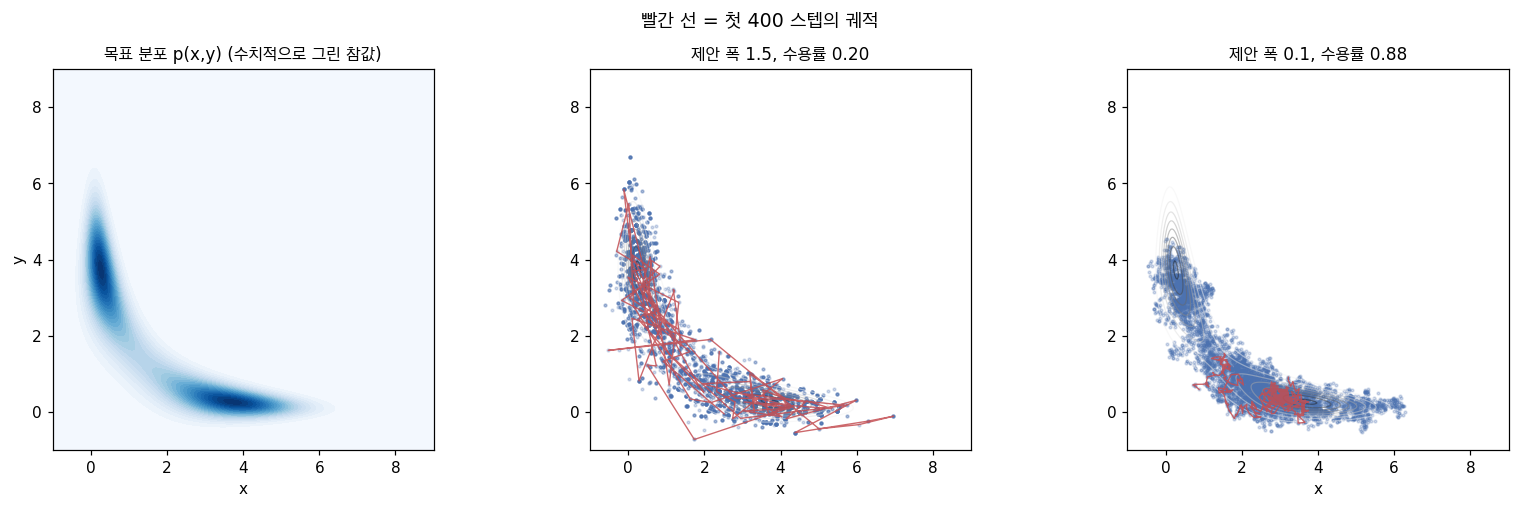

가운데(제안 폭 1.5): 두 팔을 모두 방문했습니다. 목표 분포 모양을 잘 재현합니다.
오른쪽(제안 폭 0.1): 한 팔에 갇혀 있습니다. 수용률은 높은데 탐색을 못 한 겁니다.

  제안 폭 1.5: x 평균 1.947, y 평균 1.766
  제안 폭 0.1: x 평균 1.995, y 평균 1.637

💡 '수용률이 높다 = 잘 되고 있다'가 아닙니다. 수용률이 90% 넘으면 오히려 의심하세요.


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

gx, gy = np.meshgrid(np.linspace(-1, 9, 300), np.linspace(-1, 9, 300))
gz = np.exp(-(gx ** 2 * gy ** 2 + gx ** 2 + gy ** 2 - 8 * gx - 8 * gy) / 2)

ax = axes[0]
ax.contourf(gx, gy, gz, levels=25, cmap="Blues")
ax.set_title("목표 분포 p(x,y) (수치적으로 그린 참값)", fontsize=11)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal")

for ax, std in zip(axes[1:], [1.5, 0.1]):
    s, acc = results_2d[std]
    ax.contour(gx, gy, gz, levels=8, cmap="Greys", alpha=0.5, linewidths=0.8)
    ax.scatter(s[:6000, 0], s[:6000, 1], s=3, alpha=0.25, color="#4c72b0")
    ax.plot(s[:400, 0], s[:400, 1], color="#c44e52", lw=0.9, alpha=0.85)
    ax.set_title(f"제안 폭 {std}, 수용률 {acc:.2f}", fontsize=11)
    ax.set_xlabel("x"); ax.set_xlim(-1, 9); ax.set_ylim(-1, 9); ax.set_aspect("equal")

plt.suptitle("빨간 선 = 첫 400 스텝의 궤적", fontsize=12.5)
plt.tight_layout()
plt.show()

s_good, _ = results_2d[1.5]
s_bad, _ = results_2d[0.1]
print("가운데(제안 폭 1.5): 두 팔을 모두 방문했습니다. 목표 분포 모양을 잘 재현합니다.")
print("오른쪽(제안 폭 0.1): 한 팔에 갇혀 있습니다. 수용률은 높은데 탐색을 못 한 겁니다.")
print(f"\n  제안 폭 1.5: x 평균 {s_good[:,0].mean():.3f}, y 평균 {s_good[:,1].mean():.3f}")
print(f"  제안 폭 0.1: x 평균 {s_bad[:,0].mean():.3f}, y 평균 {s_bad[:,1].mean():.3f}")
print("\n💡 '수용률이 높다 = 잘 되고 있다'가 아닙니다. 수용률이 90% 넘으면 오히려 의심하세요.")

In [34]:
print("=" * 74)
print("연습 5 — 텍스트 생성 데모: 네 가지 디코딩 전략의 다양성 비교")
print("=" * 74)

# 아주 작은 '언어모델': 직전 토큰에 따라 다음 토큰의 logit이 달라집니다
rng_lm = np.random.default_rng(77)
TRANSITION = rng_lm.normal(0, 1.6, size=(len(VOCAB), len(VOCAB)))

def next_logits(prev_idx):
    return list(TRANSITION[prev_idx])

def generate(strategy, length=20, seed=0, **kw):
    random.seed(seed)
    idx = 0
    out = []
    for _ in range(length):
        lg = next_logits(idx)
        if strategy == "greedy":
            idx = max(range(len(lg)), key=lambda i: lg[i])
        elif strategy == "temperature":
            idx = sample_from_probs(temperature_softmax(lg, kw.get("T", 0.7)))
        elif strategy == "top_k":
            p, _ = top_k_filter(softmax(lg), kw.get("k", 3))
            idx = sample_from_probs(p)
        elif strategy == "top_p":
            p, _ = top_p_filter(softmax(lg), kw.get("p", 0.9))
            idx = sample_from_probs(p)
        out.append(VOCAB[idx])
    return out

configs = [("(a) 탐욕", "greedy", {}),
           ("(b) T = 0.7", "temperature", {"T": 0.7}),
           ("(c) top-k = 3", "top_k", {"k": 3}),
           ("(d) top-p = 0.9", "top_p", {"p": 0.9})]

for label, strat, kw in configs:
    runs = [generate(strat, 20, seed=s, **kw) for s in range(5)]
    uniq_seqs = len({tuple(r) for r in runs})
    all_tokens = [t for r in runs for t in r]
    distinct1 = len(set(all_tokens)) / len(all_tokens)
    print(f"\n{label}")
    for i, r in enumerate(runs[:3]):
        print(f"    run{i+1}: {' '.join(r)}")
    print(f"    5회 실행 중 서로 다른 시퀀스: {uniq_seqs}/5")
    print(f"    distinct-1 (토큰 다양성)    : {distinct1:.3f}")

print("\n" + "-" * 74)
print("정리")
print("  (a) 탐욕     : 5번 돌려도 항상 똑같습니다. 다양성 0.")
print("  (b) T=0.7    : 다양하지만, 확률이 아주 낮은 토큰도 가끔 튀어나옵니다.")
print("  (c) top-k=3  : 꼬리를 잘라내 안정적입니다. 다만 후보 수가 항상 3개로 고정입니다.")
print("  (d) top-p=0.9: 문맥에 따라 후보 수가 달라집니다. 실무 기본값인 이유입니다.")

연습 5 — 텍스트 생성 데모: 네 가지 디코딩 전략의 다양성 비교

(a) 탐욕
    run1: 새 별 물고기 고양이 새 별 물고기 고양이 새 별 물고기 고양이 새 별 물고기 고양이 새 별 물고기 고양이
    run2: 새 별 물고기 고양이 새 별 물고기 고양이 새 별 물고기 고양이 새 별 물고기 고양이 새 별 물고기 고양이
    run3: 새 별 물고기 고양이 새 별 물고기 고양이 새 별 물고기 고양이 새 별 물고기 고양이 새 별 물고기 고양이
    5회 실행 중 서로 다른 시퀀스: 1/5
    distinct-1 (토큰 다양성)    : 0.040

(b) T = 0.7
    run1: 새 별 물고기 고양이 새 별 돌 나무 고양이 새 별 물고기 고양이 새 별 물고기 산 구름 물고기 산
    run2: 새 별 돌 나무 고양이 새 별 돌 새 새 별 물고기 나무 고양이 새 별 물고기 산 구름 물고기
    run3: 새 별 강아지 강아지 구름 물고기 물고기 고양이 새 별 돌 물고기 고양이 새 별 별 산 돌 나무 고양이
    5회 실행 중 서로 다른 시퀀스: 5/5
    distinct-1 (토큰 다양성)    : 0.100

(c) top-k = 3
    run1: 새 별 물고기 고양이 새 별 산 고양이 새 별 산 돌 나무 별 돌 물고기 산 구름 물고기 산
    run2: 새 별 돌 물고기 고양이 새 별 산 고양이 새 별 물고기 물고기 고양이 새 별 물고기 산 구름 물고기
    run3: 바다 바다 나무 고양이 새 별 돌 나무 돌 나무 돌 물고기 고양이 새 별 산 구름 물고기 고양이 새
    5회 실행 중 서로 다른 시퀀스: 5/5
    distinct-1 (토큰 다양성)    : 0.090

(d) top-p = 0.9
    run1: 새 별 물고기 고양이 새 별 산 고양이 새 별 산 돌 나무 별 돌 물고기 산 구름 물고기 산
    run2: 새 별 산 고양이 새 별 돌 나무 고양이 새 별 물고기 바다 고양이 새 별 물고기 산 구

## 1️⃣5️⃣ 📚 용어 사전 (Key Terms)

| 용어 | 사람들이 말하는 것 | 실제 의미 |
| --- | --- | --- |
| **샘플링** | "랜덤 값 뽑기" | 확률분포에 따라 값을 생성하는 것. 모든 생성형 AI의 작동 원리 |
| **균등분포** | "다 똑같이 나옴" | [a,b]의 모든 값이 밀도 1/(b−a)로 같음. 모든 샘플링의 출발점 |
| **역변환 샘플링** | "확률 변환" | `F⁻¹(U)`로 균등 샘플을 목표 분포 샘플로 변환. 정확하고 효율적 |
| **기각 샘플링** | "제안하고 채택/기각" | 간단한 제안에서 뽑고 목표/제안 비율에 따라 채택. 정확하지만 낭비가 있음 |
| **중요도 샘플링** | "가중치로 보정" | `q`에서 뽑아 `p/q`로 가중치를 주어 `p` 아래 기댓값을 추정. RL의 PPO 핵심 |
| **몬테카를로** | "무작위 평균" | 적분을 표본 평균으로 근사. 오차 `O(1/√N)`, 차원과 무관 |
| **MCMC** | "수렴하는 랜덤 워크" | 목표를 정상분포로 갖는 마르코프 연쇄를 구성. Metropolis-Hastings가 기본 |
| **Metropolis-Hastings** | "오르막은 수용, 내리막도 가끔" | 밀도 비율로 수용 여부 결정. 상세 균형이 수렴을 보장 |
| **깁스 샘플링** | "한 번에 한 변수씩" | 나머지를 고정하고 조건부에서 뽑음. 수용률 100% |
| **Temperature** | "확신 손잡이" | softmax 전에 logit을 T로 나눔. T<1 뾰족, T>1 평평 |
| **Top-k 샘플링** | "상위 k개만" | 확률 상위 k개만 남기고 재정규화. 후보 수 고정 |
| **Nucleus (top-p)** | "그럴듯한 것만" | 누적 확률이 p를 넘는 최소 집합만 유지. 후보 수 적응적 |
| **재매개변수화 트릭** | "랜덤을 밖으로" | `z = μ + σ·ε`. 샘플링을 미분 가능하게 만듦. VAE의 핵심 |
| **Gumbel-Softmax** | "부드러운 범주형 샘플링" | Gumbel 노이즈 + 온도 softmax로 범주형 샘플링을 미분 가능하게 근사 |
| **층화 샘플링** | "고르게 강제" | 공간을 층으로 나눠 각각에서 뽑음. 항상 분산이 같거나 작음 |
| **번인(burn-in)** | "워밍업" | 연쇄가 정상분포에 도달하기 전 초기 샘플을 버리는 것 |
| **상세 균형** | "가역성 조건" | `p(x)T(x→y) = p(y)T(y→x)`. p가 정상분포가 되기 위한 충분조건 |
| **디퓨전 샘플링** | "반복적 노이즈 제거" | 노이즈에서 시작해 학습된 디노이징 스텝을 반복. 각 스텝이 조건부 샘플링 |

---

## 🎯 한 문장 정리

> **우리가 직접 뽑을 수 있는 건 균등 난수 하나뿐입니다.
> 나머지 모든 샘플링 방법은 "그 하나를 어떻게 목표 분포로 바꿀 것인가"에 대한 서로 다른 답입니다.**

| 상황 | 방법 | 대가 |
| --- | --- | --- |
| CDF를 뒤집을 수 있다 | 역변환 샘플링 | 없음 (정확하고 빠름) |
| 밀도는 계산 가능, 저차원 | 기각 샘플링 | 버려지는 샘플 |
| 기댓값만 필요하다 | 중요도 샘플링 | 가중치 분산 |
| 고차원, 정규화 상수 모름 | MCMC | 상관된 샘플, 번인 |
| 조건부를 뽑을 수 있다 | 깁스 샘플링 | 상관 강하면 느림 |
| 미분해야 한다 (연속) | 재매개변수화 | 없음 (그래서 표준) |
| 미분해야 한다 (이산) | Gumbel-Softmax | 근사 오차(τ) |
| 분산을 줄이고 싶다 | 층화 샘플링 | 없음 (항상 이득) |

그리고 LLM 실무에서는 결국 이 세 손잡이로 압축됩니다.

- **temperature** — 분포를 얼마나 뾰족하게 할 것인가
- **top-k** — 후보를 몇 개로 고정할 것인가
- **top-p** — 후보를 확률 질량 기준으로 얼마나 남길 것인가

---

## 📖 더 읽을거리

- [Holbrook (2023): The Metropolis-Hastings Algorithm](https://arxiv.org/abs/2304.07010) — MCMC 기초를 다룬 상세한 튜토리얼
- [Jang, Gu, Poole (2017): Categorical Reparameterization with Gumbel-Softmax](https://arxiv.org/abs/1611.01144) — Gumbel-Softmax 원논문
- [Holtzman et al. (2020): The Curious Case of Neural Text Degeneration](https://arxiv.org/abs/1904.09751) — nucleus(top-p) 샘플링 논문
- [Kingma & Welling (2014): Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114) — 재매개변수화 트릭을 도입한 VAE 논문
- [Ho, Jain, Abbeel (2020): Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239) — 샘플링과 이미지 생성을 잇는 DDPM